In [1]:
# =============================================================================
# IMPORTS Y CONFIGURACIÓN
# =============================================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import json
import gc
import psutil
import os
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuración para plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 7)

# Paths
OUTPUT_DIR = "../data/process/"
sentences_path = f"{OUTPUT_DIR}sentences_final.parquet"
entities_path = f"{OUTPUT_DIR}entities.parquet"
main_path = f"{OUTPUT_DIR}main_cleaned.parquet"
REPORT_DIR = Path("../reports/eda/")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("EDA COMPLETO Y MEJORADO - DATASET NER")
print("="*80)

EDA COMPLETO Y MEJORADO - DATASET NER


In [2]:
# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================

def save_report(data, filename, format='json'):
    """Guarda reportes en formato JSON o CSV"""
    filepath = REPORT_DIR / filename
    if format == 'json':
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
    elif format == 'csv' and isinstance(data, (pl.DataFrame, pd.DataFrame)):
        if isinstance(data, pl.DataFrame):
            data.write_csv(filepath)
        else:
            data.to_csv(filepath, index=False)
    print(f"✓ Reporte guardado: {filepath}")

def plot_and_save(fig, filename):
    """Guarda figura y la muestra"""
    filepath = REPORT_DIR / filename
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"✓ Gráfico guardado: {filepath}")
    plt.show()

def calculate_gini(counts):
    """Calcula el coeficiente de Gini para medir desbalance"""
    sorted_counts = np.sort(counts)
    n = len(counts)
    cumsum = np.cumsum(sorted_counts)
    return (2 * np.sum((np.arange(1, n+1)) * sorted_counts)) / (n * cumsum[-1]) - (n + 1) / n

def print_section(title):
    """Imprime encabezado de sección"""
    print("\n" + "="*80)
    print(f"{title}")
    print("="*80)

def liberar_ram():
    """Libera RAM y muestra uso actual"""
    process = psutil.Process(os.getpid())
    mem_antes = process.memory_info().rss / 1024 / 1024  # MB
    
    # Colectar garbage
    gc.collect()
    
    mem_despues = process.memory_info().rss / 1024 / 1024
    print(f"RAM liberada: {mem_antes - mem_despues:.2f} MB")
    print(f"RAM actual: {mem_despues:.2f} MB")

In [3]:
# =============================================================================
# CARGA DE DATOS (usando muestreo del 33% para replicabilidad)
# =============================================================================
print_section("CARGA DE DATOS (muestra aleatoria 33%)")

sample_fraction = 0.33
random_seed = 42  # Semilla para garantizar replicabilidad

# Cargar los datos completos
main_df_full = pl.read_parquet(main_path)
entities_df_full = pl.read_parquet(entities_path)
sentences_df_full = pl.read_parquet(sentences_path).select([
    "sentence_id", 
    "sentence",
    pl.col("sentence").str.len_chars().alias("sentence_length_chars"),
    pl.col("tokens").list.len().alias("num_tokens")
])

# APLICAR SAMPLE SOBRE SENTENCES, Y FILTRAR MAIN
sentences_df = sentences_df_full.sample(fraction=sample_fraction, seed=random_seed)
sentence_ids_sample = sentences_df["sentence_id"].unique()
main_df = main_df_full.filter(pl.col("sentence_id").is_in(sentence_ids_sample))
entities_df = entities_df_full  # NO dividir entidades

print(f"✓ Sentences (muestra {sample_fraction*100:.0f}%): {sentences_df.shape}")
print(f"✓ Main (anotaciones, {sample_fraction*100:.0f}%): {main_df.shape}")
print(f"✓ Entities (completo): {entities_df.shape}")

del main_df_full, sentences_df_full
liberar_ram()

# Join ligero
entities_light = entities_df.select(["entity_id", "entity", "type_entity", "iob_tag"])
main_with_entities = main_df.join(entities_light, on="entity_id", how="left")

# Features derivadas
main_with_entities = main_with_entities.with_columns([
    (pl.col("char_end") - pl.col("char_start")).alias("entity_length_chars"),
    (pl.col("token_end") - pl.col("token_start") + 1).alias("entity_length_tokens"),
])

sentences_with_annots = main_with_entities.group_by("sentence_id").agg([
    pl.count().alias("num_entities"),
    pl.col("entity_length_chars").mean().alias("avg_entity_length"),
    pl.col("entity_length_chars").max().alias("max_entity_length")
]).join(sentences_df, on="sentence_id", how="left")

print(f"✓ Main + Entities ({sample_fraction*100:.0f}%): {main_with_entities.shape}")

del entities_light
liberar_ram()


CARGA DE DATOS (muestra aleatoria 33%)
✓ Sentences (muestra 33%): (1121796, 4)
✓ Main (anotaciones, 33%): (9007796, 7)
✓ Entities (completo): (695252, 4)
RAM liberada: 0.00 MB
RAM actual: 14705.53 MB
✓ Main + Entities (33%): (9007796, 12)
RAM liberada: 0.00 MB
RAM actual: 14973.02 MB


In [4]:
# =============================================================================
# SECCIÓN 0: ANÁLISIS DE ORACIONES (SENTENCES_DF) - Limitando datos para análisis intensivos
# =============================================================================
print_section("SECCIÓN 0: ANÁLISIS DE ORACIONES (SENTENCES_DF)")

sentences_stats = {}

# Estadísticas básicas de oraciones
print("\n--- Estadísticas Básicas de Oraciones ---")
sent_length_stats = sentences_df["sentence_length_chars"].describe()
print("Longitud de oraciones (chars):")
print(sent_length_stats)

token_stats = sentences_df["num_tokens"].describe()
print("\nNúmero de tokens por oración:")
print(token_stats)

sentences_stats['mean_sentence_length_chars'] = float(sent_length_stats.filter(pl.col("statistic") == "mean")["value"][0])
sentences_stats['median_sentence_length_chars'] = float(sent_length_stats.filter(pl.col("statistic") == "50%")["value"][0])
sentences_stats['max_sentence_length_chars'] = float(sent_length_stats.filter(pl.col("statistic") == "max")["value"][0])

sentences_stats['mean_num_tokens'] = float(token_stats.filter(pl.col("statistic") == "mean")["value"][0])
sentences_stats['median_num_tokens'] = float(token_stats.filter(pl.col("statistic") == "50%")["value"][0])
sentences_stats['max_num_tokens'] = float(token_stats.filter(pl.col("statistic") == "max")["value"][0])

# Oraciones sin entidades
annotated_sentence_ids = sentences_with_annots["sentence_id"].unique()
sentences_without_entities = sentences_df.filter(~pl.col("sentence_id").is_in(annotated_sentence_ids))
num_without_entities = len(sentences_without_entities)
pct_without_entities = 100 * num_without_entities / len(sentences_df)
print(f"\nOraciones sin entidades: {num_without_entities:,} ({pct_without_entities:.1f}%)")

sentences_stats['num_without_entities'] = num_without_entities
sentences_stats['pct_without_entities'] = pct_without_entities

# Análisis de características textuales en oraciones
print("\n--- Características Textuales en Oraciones ---")
sentences_df = sentences_df.with_columns([
    (pl.col("sentence") == pl.col("sentence").str.to_uppercase()).alias("is_all_caps"),
    (pl.col("sentence").str.slice(0, 1) == pl.col("sentence").str.slice(0, 1).str.to_uppercase()).alias("is_capitalized"),
    pl.col("sentence").str.contains(r"\d").alias("has_numbers"),
    pl.col("sentence").str.contains(r"[^a-zA-Z0-9\s]").alias("has_special_chars")
])

sent_caps_stats = sentences_df.select([
    pl.col("is_all_caps").mean().alias("pct_all_caps"),
    pl.col("is_capitalized").mean().alias("pct_capitalized"),
    pl.col("has_numbers").mean().alias("pct_with_numbers"),
    pl.col("has_special_chars").mean().alias("pct_with_special_chars")
])
print(sent_caps_stats)

sentences_stats['pct_all_caps'] = float(sent_caps_stats["pct_all_caps"][0])
sentences_stats['pct_capitalized'] = float(sent_caps_stats["pct_capitalized"][0])
sentences_stats['pct_with_numbers'] = float(sent_caps_stats["pct_with_numbers"][0])
sentences_stats['pct_with_special_chars'] = float(sent_caps_stats["pct_with_special_chars"][0])



SECCIÓN 0: ANÁLISIS DE ORACIONES (SENTENCES_DF)

--- Estadísticas Básicas de Oraciones ---
Longitud de oraciones (chars):
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1.121796e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 578.479613 │
│ std        ┆ 492.731422 │
│ min        ┆ 15.0       │
│ 25%        ┆ 266.0      │
│ 50%        ┆ 426.0      │
│ 75%        ┆ 727.0      │
│ max        ┆ 14966.0    │
└────────────┴────────────┘

Número de tokens por oración:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1.121796e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 108.310827 │
│ std        ┆ 89.932289  │
│ min        ┆ 2.0        │
│ 25%        ┆ 52.0       │
│ 50%        ┆ 81.0       │
│ 75%        ┆ 134.0      │
│ max        ┆ 2783.0     │
└─────

In [5]:

# ==== Palabras y bigramas más comunes solo sobre una muestra ====
# Limitar a 5-10% de las oraciones para análisis más costosos
sample_fraction_text = 0.10
sentences_df_sample = sentences_df.sample(fraction=sample_fraction_text, seed=random_seed)

# Análisis de palabras más comunes
print("\n--- Palabras Más Comunes en Oraciones (muestra 10%) ---")
all_words = sentences_df_sample["sentence"].str.to_lowercase().str.split(" ").explode()
word_freq = all_words.value_counts().sort("count", descending=True).head(50)
print("Top 50 palabras más frecuentes (muestra):")
print(word_freq)

save_report(word_freq.to_pandas(), 'top_words_sentences.csv', 'csv')

# Análisis de bigramas más comunes
print("\n--- Bigramas Más Comunes en Oraciones (muestra 10%) ---")
words_list = sentences_df_sample["sentence"].str.to_lowercase().str.split(" ").to_list()
bigram_list = []
for words in words_list:
    if words and len(words) > 1:
        bigram_list.extend([(words[i], words[i+1]) for i in range(len(words)-1)])
bigram_df = pl.DataFrame({"bigram": bigram_list})
bigram_freq = bigram_df["bigram"].value_counts().sort("count", descending=True).head(50)
print("Top 50 bigramas más frecuentes (muestra):")
print(bigram_freq)

save_report(bigram_freq.to_pandas(), 'top_bigrams_sentences.csv', 'csv')

# Análisis de densidad de entidades (sobre todo el conjunto, este es ligero)
print("\n--- Densidad de Entidades en Oraciones ---")
sentences_with_annots = sentences_with_annots.with_columns([
    (pl.col("num_entities") / pl.col("sentence_length_chars")).alias("entity_density_chars"),
    (pl.col("num_entities") / pl.col("num_tokens")).alias("entity_density_tokens")
])

density_stats_chars = sentences_with_annots["entity_density_chars"].describe()
density_stats_tokens = sentences_with_annots["entity_density_tokens"].describe()

print("Estadísticas de densidad de entidades (por char):")
print(density_stats_chars)

print("\nEstadísticas de densidad de entidades (por token):")
print(density_stats_tokens)

sentences_stats['mean_entity_density_chars'] = float(density_stats_chars.filter(pl.col("statistic") == "mean")["value"][0])
sentences_stats['max_entity_density_chars'] = float(density_stats_chars.filter(pl.col("statistic") == "max")["value"][0])

sentences_stats['mean_entity_density_tokens'] = float(density_stats_tokens.filter(pl.col("statistic") == "mean")["value"][0])
sentences_stats['max_entity_density_tokens'] = float(density_stats_tokens.filter(pl.col("statistic") == "max")["value"][0])

# Oraciones con alta densidad de entidades
high_density_sents = sentences_with_annots.filter(pl.col("entity_density_tokens") > sentences_stats['mean_entity_density_tokens'] * 2)
print(f"\nOraciones con alta densidad de entidades (>2x media): {len(high_density_sents)}")
if len(high_density_sents) > 0:
    print("Ejemplos:")
    print(high_density_sents.head(5).select(["sentence_id", "num_entities", "num_tokens", "entity_density_tokens"]))

# Análisis de diversidad léxica (Type-Token Ratio - TTR)
# Para este análisis, también limitamos a una muestra del 10% (ya que requiere función sobre cada fila).
print("\n--- Diversidad Léxica (Type-Token Ratio, muestra 10%) ---")
def calculate_ttr(words):
    if len(words) == 0:
        return 0.0
    unique_words = len(set(words))
    return unique_words / len(words)

sentences_df_ttr_sample = sentences_df.sample(fraction=sample_fraction_text, seed=random_seed+1)
sentences_df_ttr_sample = sentences_df_ttr_sample.with_columns(
    pl.col("sentence").str.to_lowercase().str.split(" ").alias("words")
).with_columns(
    pl.col("words").map_elements(calculate_ttr, return_dtype=pl.Float64).alias("ttr")
)

ttr_stats = sentences_df_ttr_sample["ttr"].describe()
print("Estadísticas de TTR (muestra):")
print(ttr_stats)

sentences_stats['mean_ttr'] = float(ttr_stats.filter(pl.col("statistic") == "mean")["value"][0])
sentences_stats['min_ttr'] = float(ttr_stats.filter(pl.col("statistic") == "min")["value"][0])

# Oraciones con baja diversidad léxica
low_ttr_sents = sentences_df_ttr_sample.filter(pl.col("ttr") < sentences_stats['mean_ttr'] * 0.5)
print(f"\nOraciones con baja diversidad léxica (<0.5x media TTR, muestra): {len(low_ttr_sents)}")
if len(low_ttr_sents) > 0:
    print("Ejemplos:")
    print(low_ttr_sents.head(5).select(["sentence_id", "sentence", "ttr"]))

# Oraciones muy cortas o largas (esto es barato, se hace sobre todo el corpus)
very_short_sents = sentences_df.filter(pl.col("sentence_length_chars") <= 10)
very_long_sents = sentences_df.filter(pl.col("sentence_length_chars") > 5000)

print(f"\nOraciones muy cortas (≤10 chars): {len(very_short_sents)}")
if len(very_short_sents) > 0:
    print("Ejemplos:")
    print(very_short_sents.head(5).select(["sentence_id", "sentence", "sentence_length_chars"]))

print(f"\nOraciones muy largas (>5000 chars): {len(very_long_sents)}")
if len(very_long_sents) > 0:
    print("Ejemplos:")
    print(very_long_sents.head(5).select(["sentence_id", "sentence_length_chars"]))

sentences_stats['num_very_short'] = len(very_short_sents)
sentences_stats['num_very_long'] = len(very_long_sents)

# Análisis de oraciones puramente numéricas o con solo especiales (baratos)
pure_numeric_sents = sentences_df.filter(pl.col("sentence").str.contains(r"^\d+$"))
pure_special_sents = sentences_df.filter(pl.col("sentence").str.contains(r"^[^a-zA-Z0-9\s]+$"))

print(f"\nOraciones puramente numéricas: {len(pure_numeric_sents)}")
if len(pure_numeric_sents) > 0:
    print("Ejemplos:")
    print(pure_numeric_sents.head(5).select(["sentence_id", "sentence"]))

print(f"\nOraciones con solo caracteres especiales: {len(pure_special_sents)}")
if len(pure_special_sents) > 0:
    print("Ejemplos:")
    print(pure_special_sents.head(5).select(["sentence_id", "sentence"]))

sentences_stats['num_pure_numeric'] = len(pure_numeric_sents)
sentences_stats['num_pure_special'] = len(pure_special_sents)



--- Palabras Más Comunes en Oraciones (muestra 10%) ---
Top 50 palabras más frecuentes (muestra):
shape: (50, 2)
┌──────────┬────────┐
│ sentence ┆ count  │
│ ---      ┆ ---    │
│ str      ┆ u32    │
╞══════════╪════════╡
│ and      ┆ 466311 │
│ the      ┆ 342323 │
│ 1        ┆ 286610 │
│ in       ┆ 239872 │
│ to       ┆ 229430 │
│ …        ┆ …      │
│ sugar,   ┆ 34502  │
│ oven     ┆ 34376  │
│ chicken  ┆ 33358  │
│ water    ┆ 32872  │
│ can      ┆ 31781  │
└──────────┴────────┘
✓ Reporte guardado: ../reports/eda/top_words_sentences.csv

--- Bigramas Más Comunes en Oraciones (muestra 10%) ---
Top 50 bigramas más frecuentes (muestra):
shape: (50, 2)
┌────────────────────┬───────┐
│ bigram             ┆ count │
│ ---                ┆ ---   │
│ list[str]          ┆ u32   │
╞════════════════════╪═══════╡
│ ["in", "a"]        ┆ 67871 │
│ ["in", "the"]      ┆ 32128 │
│ ["of", "the"]      ┆ 28831 │
│ ["1", "cup"]       ┆ 28628 │
│ ["salt", "and"]    ┆ 27180 │
│ …                  ┆ …     

✓ Gráfico guardado: ../reports/eda/sentences_analysis.png


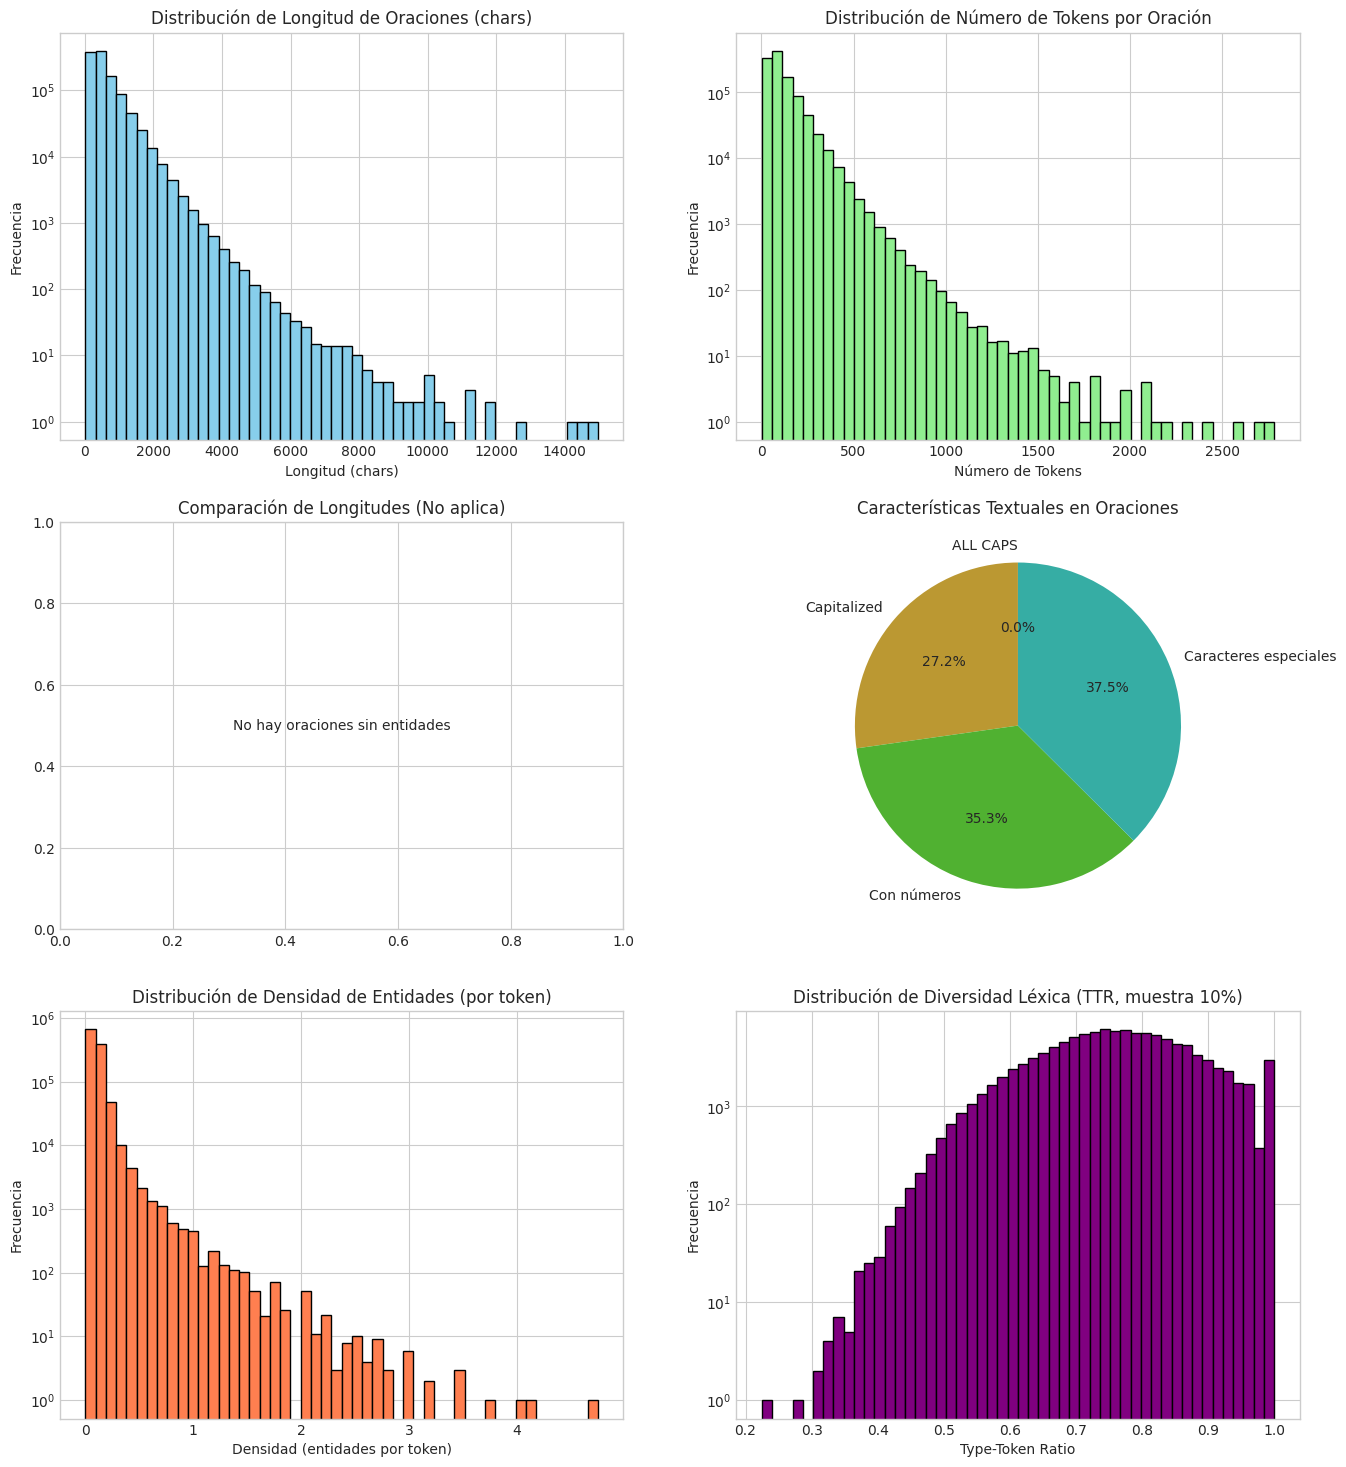

✓ Reporte guardado: ../reports/eda/sentences_stats.json
RAM liberada: 35.60 MB
RAM actual: 16615.20 MB


In [6]:

# Plots principales sobre todo el set de oraciones (no muestra)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

axes[0,0].hist(sentences_df["sentence_length_chars"].to_numpy(), bins=50, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel("Longitud (chars)")
axes[0,0].set_ylabel("Frecuencia")
axes[0,0].set_title("Distribución de Longitud de Oraciones (chars)")
axes[0,0].set_yscale('log')

axes[0,1].hist(sentences_df["num_tokens"].to_numpy(), bins=50, color='lightgreen', edgecolor='black')
axes[0,1].set_xlabel("Número de Tokens")
axes[0,1].set_ylabel("Frecuencia")
axes[0,1].set_title("Distribución de Número de Tokens por Oración")
axes[0,1].set_yscale('log')

# Boxplot comparativo con vs sin entidades (si aplica)
if num_without_entities > 0:
    with_entities_lengths = sentences_with_annots["sentence_length_chars"].to_numpy()
    without_entities_lengths = sentences_without_entities["sentence_length_chars"].to_numpy()
    
    sns.boxplot(data=pd.DataFrame({
        'Longitud': np.concatenate([with_entities_lengths, without_entities_lengths]),
        'Tipo': ['Con Entidades'] * len(with_entities_lengths) + ['Sin Entidades'] * len(without_entities_lengths)
    }), x='Tipo', y='Longitud', ax=axes[1,0])
    axes[1,0].set_title("Comparación de Longitudes de Oraciones")
    axes[1,0].set_yscale('log')
else:
    axes[1,0].text(0.5, 0.5, "No hay oraciones sin entidades", horizontalalignment='center', verticalalignment='center')
    axes[1,0].set_title("Comparación de Longitudes (No aplica)")

# Pie chart de características textuales en oraciones
char_features_sent = [
    sentences_stats['pct_all_caps'] * 100,
    sentences_stats['pct_capitalized'] * 100,
    sentences_stats['pct_with_numbers'] * 100,
    sentences_stats['pct_with_special_chars'] * 100
]
labels = ['ALL CAPS', 'Capitalized', 'Con números', 'Caracteres especiales']
axes[1,1].pie(char_features_sent, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title("Características Textuales en Oraciones")

# Histograma de densidad de entidades
axes[2,0].hist(sentences_with_annots["entity_density_tokens"].to_numpy(), bins=50, color='coral', edgecolor='black')
axes[2,0].set_xlabel("Densidad (entidades por token)")
axes[2,0].set_ylabel("Frecuencia")
axes[2,0].set_title("Distribución de Densidad de Entidades (por token)")
axes[2,0].set_yscale('log')

# Histograma de TTR (usando la muestra)
axes[2,1].hist(sentences_df_ttr_sample["ttr"].to_numpy(), bins=50, color='purple', edgecolor='black')
axes[2,1].set_xlabel("Type-Token Ratio")
axes[2,1].set_ylabel("Frecuencia")
axes[2,1].set_title("Distribución de Diversidad Léxica (TTR, muestra 10%)")
axes[2,1].set_yscale('log')

plot_and_save(fig, 'sentences_analysis.png')

save_report(sentences_stats, 'sentences_stats.json')

del sent_length_stats, token_stats, sentences_without_entities, annotated_sentence_ids, all_words, word_freq, bigram_df, bigram_freq, density_stats_chars, density_stats_tokens, low_ttr_sents, very_short_sents, very_long_sents, sent_caps_stats, pure_numeric_sents, pure_special_sents
if 'with_entities_lengths' in locals():
    del with_entities_lengths, without_entities_lengths
liberar_ram()

In [7]:
# =============================================================================
# SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES
# =============================================================================
print_section("SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES")

quality_report = {}

# 1.1 Valores nulos
print("\n--- Valores Nulos ---")
null_counts = main_with_entities.null_count()
print(null_counts)
quality_report['null_counts'] = {col: int(null_counts[col][0]) for col in null_counts.columns}

# 1.2 Duplicados
print("\n--- Duplicados ---")
duplicates = main_with_entities.filter(
    pl.struct(["sentence_id", "char_start", "char_end", "entity"]).is_duplicated()
)
print(f"Anotaciones duplicadas: {len(duplicates)} ({100*len(duplicates)/len(main_with_entities):.2f}%)")
quality_report['duplicates'] = len(duplicates)

if len(duplicates) > 0:
    print("\nEjemplos de duplicados (top 5):")
    print(duplicates.head(5).select(["sentence_id", "entity", "type_entity", "char_start", "char_end"]))

# 1.3 Inconsistencias: misma entidad, diferentes tipos
print("\n--- Inconsistencias de Tipos ---")
entity_type_conflicts = entities_df.group_by("entity").agg([
    pl.col("type_entity").n_unique().alias("num_types"),
    pl.col("type_entity").alias("types")
]).filter(pl.col("num_types") > 1).sort("num_types", descending=True)

print(f"Entidades con múltiples tipos: {len(entity_type_conflicts)}")
quality_report['ambiguous_entities'] = len(entity_type_conflicts)

if len(entity_type_conflicts) > 0:
    print("\nTop 10 entidades ambiguas:")
    print(entity_type_conflicts.head(10))
    save_report(entity_type_conflicts.to_pandas(), 'ambiguous_entities.csv', 'csv')


SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES

--- Valores Nulos ---
shape: (1, 12)
┌────────────┬───────────┬───────────┬───────────┬───┬───────────┬─────────┬───────────┬───────────┐
│ entity_loc ┆ sentence_ ┆ entity_id ┆ char_star ┆ … ┆ type_enti ┆ iob_tag ┆ entity_le ┆ entity_le │
│ al_id      ┆ id        ┆ ---       ┆ t         ┆   ┆ ty        ┆ ---     ┆ ngth_char ┆ ngth_toke │
│ ---        ┆ ---       ┆ u32       ┆ ---       ┆   ┆ ---       ┆ u32     ┆ s         ┆ ns        │
│ u32        ┆ u32       ┆           ┆ u32       ┆   ┆ u32       ┆         ┆ ---       ┆ ---       │
│            ┆           ┆           ┆           ┆   ┆           ┆         ┆ u32       ┆ u32       │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═════════╪═══════════╪═══════════╡
│ 0          ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0       ┆ 0         ┆ 0         │
└────────────┴───────────┴───────────┴───────────┴───┴───────────┴─────────┴───────────┴───────────┘

--- Dupl

Anotaciones duplicadas: 332221 (3.69%)

Ejemplos de duplicados (top 5):
shape: (5, 5)
┌─────────────┬────────┬─────────────┬────────────┬──────────┐
│ sentence_id ┆ entity ┆ type_entity ┆ char_start ┆ char_end │
│ ---         ┆ ---    ┆ ---         ┆ ---        ┆ ---      │
│ str         ┆ str    ┆ str         ┆ i64        ┆ i64      │
╞═════════════╪════════╪═════════════╪════════════╪══════════╡
│ SENT_22544  ┆ butter ┆ FOOD        ┆ 7          ┆ 13       │
│ SENT_22544  ┆ butter ┆ FOOD        ┆ 7          ┆ 13       │
│ SENT_22548  ┆ sugar  ┆ FOOD        ┆ 63         ┆ 68       │
│ SENT_22548  ┆ sugar  ┆ FOOD        ┆ 63         ┆ 68       │
│ SENT_22554  ┆ sugar  ┆ FOOD        ┆ 85         ┆ 90       │
└─────────────┴────────┴─────────────┴────────────┴──────────┘

--- Inconsistencias de Tipos ---
Entidades con múltiples tipos: 329

Top 10 entidades ambiguas:
shape: (10, 3)
┌───────────┬───────────┬───────────────────────────────┐
│ entity    ┆ num_types ┆ types                    

In [8]:
# 1.4 Overlaps: anotaciones solapadas
print("\n--- Overlaps (Anotaciones Solapadas) ---")
overlaps = main_df.sort(["sentence_id", "char_start"]).with_columns([
    pl.col("char_end").shift(1).over("sentence_id").alias("prev_end"),
    pl.col("sentence_id").shift(1).alias("prev_sent"),
    pl.col("entity_id").shift(1).over("sentence_id").alias("prev_entity_id")
]).filter(
    (pl.col("sentence_id") == pl.col("prev_sent")) & 
    (pl.col("char_start") < pl.col("prev_end"))
)

print(f"Anotaciones con overlap: {len(overlaps)} ({100*len(overlaps)/len(main_df):.2f}%)")
quality_report['overlaps'] = len(overlaps)

if len(overlaps) > 0:
    print("\nEjemplos de overlaps (top 5):")
    print(overlaps.head(5).select(["sentence_id", "entity_id", "prev_entity_id", "char_start", "char_end", "prev_end"]))

# 1.5 Posiciones inválidas
print("\n--- Posiciones Inválidas ---")
invalid_positions = main_df.join(
    sentences_df.select(["sentence_id", "num_tokens"]), 
    on="sentence_id"
).filter(pl.col("token_end") >= pl.col("num_tokens"))

print(f"Anotaciones fuera de rango de tokens: {len(invalid_positions)}")
quality_report['invalid_positions'] = len(invalid_positions)

# 1.6 Validación de longitudes (negativos, ceros)
invalid_lengths = main_with_entities.filter(
    (pl.col("entity_length_chars") <= 0) | 
    (pl.col("entity_length_tokens") <= 0)
)
print(f"Entidades con longitud inválida: {len(invalid_lengths)}")
quality_report['invalid_lengths'] = len(invalid_lengths)

# Guardar reporte de calidad
save_report(quality_report, 'quality_report.json')

del null_counts, duplicates, entity_type_conflicts, overlaps, invalid_positions, invalid_lengths
liberar_ram()


--- Overlaps (Anotaciones Solapadas) ---
Anotaciones con overlap: 309384 (3.43%)

Ejemplos de overlaps (top 5):
shape: (5, 6)
┌─────────────┬────────────┬────────────────┬────────────┬──────────┬──────────┐
│ sentence_id ┆ entity_id  ┆ prev_entity_id ┆ char_start ┆ char_end ┆ prev_end │
│ ---         ┆ ---        ┆ ---            ┆ ---        ┆ ---      ┆ ---      │
│ str         ┆ str        ┆ str            ┆ i64        ┆ i64      ┆ i64      │
╞═════════════╪════════════╪════════════════╪════════════╪══════════╪══════════╡
│ SENT_00045  ┆ UENT_00090 ┆ UENT_00111     ┆ 56         ┆ 60       ┆ 60       │
│ SENT_00130  ┆ UENT_00015 ┆ UENT_00626     ┆ 235        ┆ 238      ┆ 244      │
│ SENT_00179  ┆ UENT_00010 ┆ UENT_00091     ┆ 65         ┆ 71       ┆ 75       │
│ SENT_00291  ┆ UENT_00165 ┆ UENT_00155     ┆ 13         ┆ 17       ┆ 17       │
│ SENT_00310  ┆ UENT_00145 ┆ UENT_00067     ┆ 147        ┆ 155      ┆ 156      │
└─────────────┴────────────┴────────────────┴────────────┴─────

In [9]:
# =============================================================================
# SECCIÓN 2: VALIDACIÓN DE SECUENCIAS IOB
# =============================================================================
print_section("SECCIÓN 2: VALIDACIÓN DE SECUENCIAS IOB")

iob_report = {}

# 2.1 Consistencia de secuencias IOB
print("\n--- Validación de Secuencias IOB ---")
iob_validation = main_with_entities.sort(["sentence_id", "token_start"]).with_columns([
    pl.col("iob_tag").shift(1).over("sentence_id").alias("prev_iob"),
    pl.col("type_entity").shift(1).over("sentence_id").alias("prev_type")
])

# I- debe seguir a B- o I- del mismo tipo
invalid_iob = iob_validation.filter(
    (pl.col("iob_tag").str.contains("^I-")) &
    (
        (~pl.col("prev_iob").str.contains("^[BI]-")) |
        (pl.col("type_entity") != pl.col("prev_type"))
    )
)

print(f"Secuencias IOB inválidas: {len(invalid_iob)} ({100*len(invalid_iob)/len(main_with_entities):.2f}%)")
iob_report['invalid_sequences'] = len(invalid_iob)

if len(invalid_iob) > 0:
    print("\nEjemplos de secuencias inválidas (top 5):")
    print(invalid_iob.head(5).select(["sentence_id", "entity", "type_entity", "iob_tag", "prev_iob", "prev_type"]))

# 2.2 Longitud de secuencias (cuántos tokens por entidad)
print("\n--- Longitud de Secuencias IOB ---")

# Método más robusto para calcular longitud de secuencias
sequence_lengths = main_with_entities.sort(["sentence_id", "token_start"]).with_columns([
    # Identificar inicio de nuevas entidades
    pl.when(pl.col("iob_tag").str.starts_with("B-"))
      .then(1)
      .when(pl.col("iob_tag") == "O")
      .then(0)
      .when(
          (pl.col("iob_tag").str.starts_with("I-")) & 
          (pl.col("iob_tag").shift(1).over("sentence_id").str.starts_with("B-") |
           pl.col("iob_tag").shift(1).over("sentence_id").str.starts_with("I-"))
      )
      .then(0)
      .otherwise(1)
      .alias("new_entity_flag")
]).with_columns([
    # Crear ID único para cada secuencia de entidad
    pl.col("new_entity_flag").cum_sum().over("sentence_id").alias("entity_seq_id")
]).filter(
    # Filtrar solo tokens que son parte de entidades (no 'O')
    pl.col("iob_tag") != "O"
).group_by(["sentence_id", "entity_seq_id"]).agg([
    pl.count().alias("seq_length"),
    pl.col("type_entity").first().alias("type_entity")
])

# Si no hay secuencias, crear un DataFrame vacío con la estructura esperada
if len(sequence_lengths) == 0:
    sequence_lengths = pl.DataFrame({
        "sentence_id": [],
        "entity_seq_id": [],
        "seq_length": [],
        "type_entity": []
    })

# Calcular estadísticas
if len(sequence_lengths) > 0:
    # Convertir a pandas para usar describe() y obtener los nombres de columna correctos
    seq_lengths_pd = sequence_lengths.to_pandas()
    seq_stats = seq_lengths_pd["seq_length"].describe()
    print("Estadísticas de longitud de secuencias IOB:")
    print(seq_stats)
    
    # Longitud de secuencias por tipo
    seq_by_type = sequence_lengths.group_by("type_entity").agg([
        pl.col("seq_length").mean().alias("avg_seq_length"),
        pl.col("seq_length").max().alias("max_seq_length"),
        pl.count().alias("num_sequences")
    ]).sort("avg_seq_length", descending=True)

    print("\nLongitud de secuencias por tipo (top 10):")
    print(seq_by_type.head(10))

    iob_report['sequence_stats'] = {
        'mean': float(seq_stats["mean"]),
        'max': float(seq_stats["max"]),
        'total_sequences': int(seq_stats["count"])
    }
else:
    print("No se encontraron secuencias de entidades para analizar.")
    iob_report['sequence_stats'] = {
        'mean': 0,
        'max': 0,
        'total_sequences': 0
    }

save_report(iob_report, 'iob_validation_report.json')

del iob_validation, invalid_iob, sequence_lengths, seq_lengths_pd, seq_by_type, seq_stats
liberar_ram()


SECCIÓN 2: VALIDACIÓN DE SECUENCIAS IOB

--- Validación de Secuencias IOB ---
Secuencias IOB inválidas: 0 (0.00%)

--- Longitud de Secuencias IOB ---
Estadísticas de longitud de secuencias IOB:
count    9007796.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
Name: seq_length, dtype: float64

Longitud de secuencias por tipo (top 10):
shape: (9, 4)
┌──────────────────┬────────────────┬────────────────┬───────────────┐
│ type_entity      ┆ avg_seq_length ┆ max_seq_length ┆ num_sequences │
│ ---              ┆ ---            ┆ ---            ┆ ---           │
│ str              ┆ f64            ┆ u32            ┆ u32           │
╞══════════════════╪════════════════╪════════════════╪═══════════════╡
│ TASTE            ┆ 1.0            ┆ 1              ┆ 38            │
│ COLOR            ┆ 1.0            ┆ 1              ┆ 53            │
│ PHYSICAL_QUALITY ┆ 1.0            ┆ 1              ┆ 219        

In [10]:
# =============================================================================
# SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA
# =============================================================================
print_section("SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA")
liberar_ram()
basic_stats = {}

# Totales
total_annots = len(main_with_entities)
unique_entities = main_with_entities['entity_id'].n_unique()
unique_sentences = main_with_entities['sentence_id'].n_unique()

print(f"Total anotaciones: {total_annots:,}")
print(f"Entidades únicas: {unique_entities:,}")
print(f"Oraciones con anotaciones: {unique_sentences:,}")

basic_stats['total_annotations'] = total_annots
basic_stats['unique_entities'] = unique_entities
basic_stats['annotated_sentences'] = unique_sentences

# Cobertura
total_sentences = len(sentences_df)
coverage = 100 * unique_sentences / total_sentences
print(f"\nCobertura: {coverage:.1f}% ({unique_sentences:,} / {total_sentences:,} oraciones)")
basic_stats['coverage_pct'] = float(coverage)

# Entidades por oración
annots_per_sent = sentences_with_annots["num_entities"].describe()
print("\nEntidades por oración:")
print(annots_per_sent)

# Análisis de percentiles detallado
print("\n--- Análisis de Percentiles (Entidades por Oración) ---")
num_entities_arr = sentences_with_annots["num_entities"].to_numpy()
percentiles = [50, 75, 90, 95, 97.5, 99, 99.5, 99.9, 100]
percentile_values = {p: np.percentile(num_entities_arr, p) for p in percentiles}

for p in percentiles:
    p_value = percentile_values[p]
    sents_above = sentences_with_annots.filter(pl.col("num_entities") > p_value)
    print(f"P{p}: {p_value:.1f} entidades | {len(sents_above)} oraciones sobre este umbral")

# Identificar oraciones extremas
extreme_sentences = sentences_with_annots.filter(pl.col("num_entities") > percentile_values[99]).sort("num_entities", descending=True)
print(f"\nOraciones en top 1% (>{percentile_values[99]:.0f} entidades): {len(extreme_sentences)}")
print("\nTop 10 oraciones con más entidades:")
print(extreme_sentences.head(10).select(["sentence_id", "num_entities", "sentence_length_chars"]))

save_report(basic_stats, 'basic_stats.json')

del annots_per_sent, num_entities_arr, sents_above, extreme_sentences
liberar_ram()


SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA
RAM liberada: 0.00 MB
RAM actual: 16314.43 MB
Total anotaciones: 9,007,796
Entidades únicas: 370,140
Oraciones con anotaciones: 1,121,796

Cobertura: 100.0% (1,121,796 / 1,121,796 oraciones)

Entidades por oración:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1.121796e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 8.029799   │
│ std        ┆ 4.193921   │
│ min        ┆ 1.0        │
│ 25%        ┆ 5.0        │
│ 50%        ┆ 7.0        │
│ 75%        ┆ 10.0       │
│ max        ┆ 402.0      │
└────────────┴────────────┘

--- Análisis de Percentiles (Entidades por Oración) ---
P50: 7.0 entidades | 555248 oraciones sobre este umbral
P75: 10.0 entidades | 250484 oraciones sobre este umbral
P90: 13.0 entidades | 99053 oraciones sobre este umbral
P95: 15.0 entidades | 54365 oraciones sobre este umbral
P97.5: 18.0 entidades | 


SECCIÓN 4: DISTRIBUCIÓN DE TIPOS Y DESBALANCE
RAM liberada: 0.00 MB
RAM actual: 16357.77 MB
Distribución de tipos de entidades:
shape: (9, 2)
┌──────────────────┬─────────┐
│ type_entity      ┆ count   │
│ ---              ┆ ---     │
│ str              ┆ u32     │
╞══════════════════╪═════════╡
│ FOOD             ┆ 9004862 │
│ QUANTITY         ┆ 1190    │
│ UNIT             ┆ 1002    │
│ PROCESS          ┆ 372     │
│ PHYSICAL_QUALITY ┆ 219     │
│ COLOR            ┆ 53      │
│ PURPOSE          ┆ 47      │
│ TASTE            ┆ 38      │
│ PART             ┆ 13      │
└──────────────────┴─────────┘

--- Métricas de Desbalance ---
Coeficiente de Gini: 0.889 (0=balance perfecto, 1=máximo desbalance)
Entropía: 0.003 (mayor=más uniforme)
Ratio max/min: 692681.7x

Tipos raros (<1% = 90078 anotaciones): 8
shape: (8, 2)
┌──────────────────┬───────┐
│ type_entity      ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ QUANTITY         ┆ 1190  │

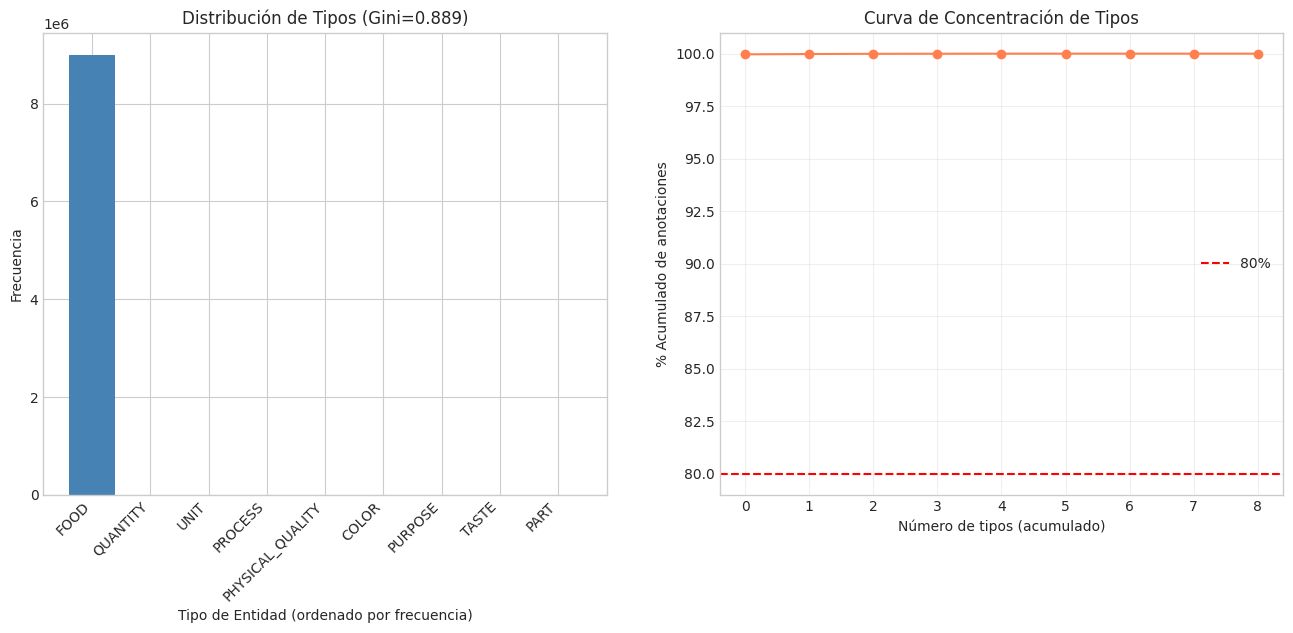

✓ Reporte guardado: ../reports/eda/type_stats.json
RAM liberada: 0.00 MB
RAM actual: 16369.61 MB


In [11]:
# =============================================================================
# SECCIÓN 4: DISTRIBUCIÓN DE TIPOS Y ANÁLISIS DE DESBALANCE
# =============================================================================
print_section("SECCIÓN 4: DISTRIBUCIÓN DE TIPOS Y DESBALANCE")
liberar_ram()

type_stats = {}

# Distribución de tipos
type_dist = main_with_entities["type_entity"].value_counts().sort("count", descending=True)
print("Distribución de tipos de entidades:")
print(type_dist)

# Métricas de desbalance
type_counts = type_dist["count"].to_numpy()
gini = calculate_gini(type_counts)
ent = entropy(type_counts / type_counts.sum())
max_ratio = type_counts.max() / type_counts.min()

print(f"\n--- Métricas de Desbalance ---")
print(f"Coeficiente de Gini: {gini:.3f} (0=balance perfecto, 1=máximo desbalance)")
print(f"Entropía: {ent:.3f} (mayor=más uniforme)")
print(f"Ratio max/min: {max_ratio:.1f}x")

type_stats['gini_coefficient'] = float(gini)
type_stats['entropy'] = float(ent)
type_stats['max_min_ratio'] = float(max_ratio)
type_stats['num_types'] = len(type_dist)

# Tipos raros (< 1% del total)
rare_threshold = 0.01 * total_annots
rare_types = type_dist.filter(pl.col("count") < rare_threshold)
print(f"\nTipos raros (<1% = {rare_threshold:.0f} anotaciones): {len(rare_types)}")
if len(rare_types) > 0:
    print(rare_types)
type_stats['rare_types_count'] = len(rare_types)

# Distribución IOB
iob_dist = main_with_entities["iob_tag"].value_counts().sort("count", descending=True)
print("\nDistribución de IOB tags (top 15):")
print(iob_dist.head(15))

# Plot distribución de tipos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_dist_pd = type_dist.to_pandas()
axes[0].bar(range(len(type_dist_pd)), type_dist_pd["count"], color='steelblue')
axes[0].set_xlabel("Tipo de Entidad (ordenado por frecuencia)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title(f"Distribución de Tipos (Gini={gini:.3f})")
axes[0].set_xticks(range(len(type_dist_pd)))
axes[0].set_xticklabels(type_dist_pd["type_entity"], rotation=45, ha='right')

# Acumulado
cumsum = np.cumsum(type_dist_pd["count"]) / type_dist_pd["count"].sum() * 100
axes[1].plot(range(len(cumsum)), cumsum, marker='o', color='coral')
axes[1].axhline(80, color='red', linestyle='--', label='80%')
axes[1].set_xlabel("Número de tipos (acumulado)")
axes[1].set_ylabel("% Acumulado de anotaciones")
axes[1].set_title("Curva de Concentración de Tipos")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plot_and_save(fig, 'type_distribution.png')

save_report(type_stats, 'type_stats.json')

del type_dist_pd, type_counts, rare_types, cumsum
liberar_ram()


SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES
RAM liberada: 0.00 MB
RAM actual: 16369.86 MB
Estadísticas de longitud de entidades (chars):
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 9.007796e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 8.180175   │
│ std        ┆ 4.744148   │
│ min        ┆ 0.0        │
│ 25%        ┆ 5.0        │
│ 50%        ┆ 7.0        │
│ 75%        ┆ 11.0       │
│ max        ┆ 145.0      │
└────────────┴────────────┘

Longitud de entidades por tipo:
shape: (9, 7)
┌──────────────────┬─────────────┬───────────────┬────────────┬────────────┬────────────┬─────────┐
│ type_entity      ┆ mean_length ┆ median_length ┆ std_length ┆ min_length ┆ max_length ┆ count   │
│ ---              ┆ ---         ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---     │
│ str              ┆ f64         ┆ f64           ┆ f64        ┆

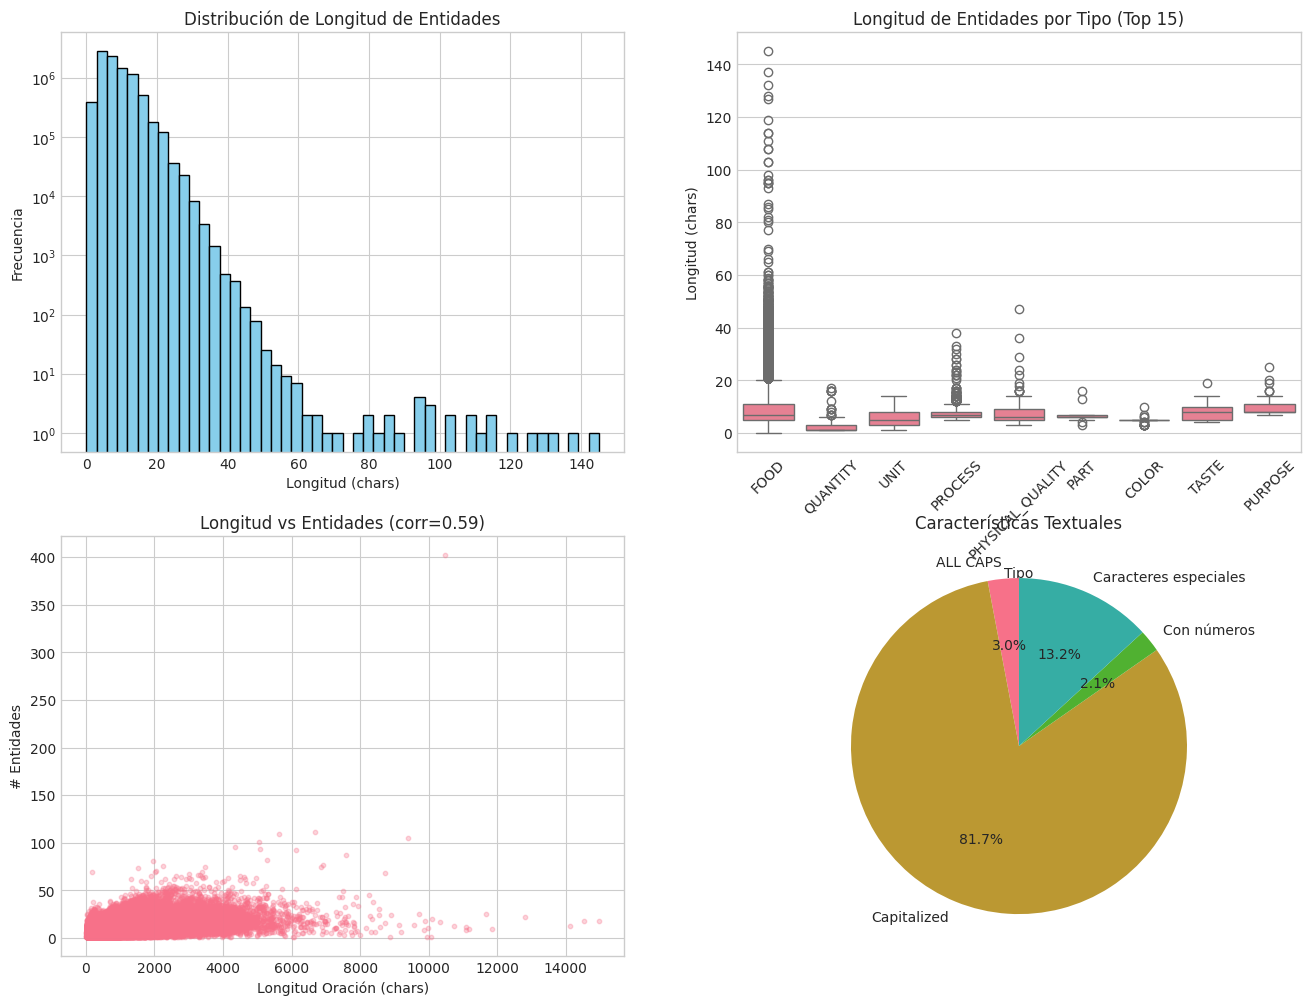

✓ Reporte guardado: ../reports/eda/text_analysis.json
RAM liberada: 0.00 MB
RAM actual: 14538.88 MB


In [12]:
# =============================================================================
# SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES
# =============================================================================
print_section("SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES")
liberar_ram()

text_analysis = {}

# Estadísticas de longitud de entidades
length_stats = main_with_entities["entity_length_chars"].describe()
print("Estadísticas de longitud de entidades (chars):")
print(length_stats)

# Longitudes por tipo
length_by_type = main_with_entities.group_by("type_entity").agg([
    pl.col("entity_length_chars").mean().alias("mean_length"),
    pl.col("entity_length_chars").median().alias("median_length"),
    pl.col("entity_length_chars").std().alias("std_length"),
    pl.col("entity_length_chars").min().alias("min_length"),
    pl.col("entity_length_chars").max().alias("max_length"),
    pl.count().alias("count")
]).sort("mean_length", descending=True)

print("\nLongitud de entidades por tipo:")
print(length_by_type)

# Tipos con mayor variabilidad
print("\nTipos con mayor variabilidad en longitud (top 5):")
print(length_by_type.sort("std_length", descending=True).head(5))

# Análisis de características textuales
print("\n--- Características Textuales ---")
main_with_entities = main_with_entities.with_columns([
    pl.col("entity").str.to_uppercase().alias("entity_upper"),
    (pl.col("entity") == pl.col("entity").str.to_uppercase()).alias("is_all_caps"),
    (pl.col("entity").str.slice(0, 1) == pl.col("entity").str.slice(0, 1).str.to_uppercase()).alias("is_capitalized"),
    pl.col("entity").str.contains(r"\d").alias("has_numbers"),
    pl.col("entity").str.contains(r"[^a-zA-Z0-9\s]").alias("has_special_chars")
])

caps_stats = main_with_entities.select([
    pl.col("is_all_caps").sum().alias("all_caps"),
    pl.col("is_capitalized").sum().alias("capitalized"),
    pl.col("has_numbers").sum().alias("with_numbers"),
    pl.col("has_special_chars").sum().alias("with_special_chars")
])
print(caps_stats)

text_analysis['all_caps_pct'] = float(100 * caps_stats["all_caps"][0] / total_annots)
text_analysis['with_numbers_pct'] = float(100 * caps_stats["with_numbers"][0] / total_annots)

# Entidades muy cortas (posibles errores)
very_short = main_with_entities.filter(pl.col("entity_length_chars") <= 2)
print(f"\nEntidades muy cortas (≤2 chars): {len(very_short)} ({100*len(very_short)/total_annots:.2f}%)")
print("Ejemplos:")
print(very_short.head(10).select(["entity", "type_entity", "entity_length_chars"]))

# Entidades muy largas
very_long = main_with_entities.filter(pl.col("entity_length_chars") > 100)
print(f"\nEntidades muy largas (>100 chars): {len(very_long)}")
if len(very_long) > 0:
    print("Top 5 más largas:")
    print(very_long.sort("entity_length_chars", descending=True).head(5).select(["entity", "type_entity", "entity_length_chars"]))

# Correlación longitud oración vs # entidades
corr_length_annots = sentences_with_annots.select([
    pl.corr("sentence_length_chars", "num_entities").alias("corr")
]).item()
print(f"\nCorrelación longitud oración vs # entidades: {corr_length_annots:.3f}")
text_analysis['corr_sent_length_num_entities'] = float(corr_length_annots)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histograma de longitudes de entidades (con escala log)
axes[0,0].hist(main_with_entities["entity_length_chars"].to_numpy(), bins=50, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel("Longitud (chars)")
axes[0,0].set_ylabel("Frecuencia")
axes[0,0].set_title("Distribución de Longitud de Entidades")
axes[0,0].set_yscale('log')

# Boxplot por tipo (top 15 tipos)
top_15_types = type_dist.head(15)["type_entity"].to_list()
data_top15 = main_with_entities.filter(pl.col("type_entity").is_in(top_15_types))
sns.boxplot(data=data_top15.to_pandas(), x="type_entity", y="entity_length_chars", ax=axes[0,1])
axes[0,1].set_xlabel("Tipo")
axes[0,1].set_ylabel("Longitud (chars)")
axes[0,1].set_title("Longitud de Entidades por Tipo (Top 15)")
axes[0,1].tick_params(axis='x', rotation=45)

# Scatter: longitud oración vs # entidades
scatter_data = sentences_with_annots.to_pandas()
axes[1,0].scatter(scatter_data["sentence_length_chars"], scatter_data["num_entities"], alpha=0.3, s=10)
axes[1,0].set_xlabel("Longitud Oración (chars)")
axes[1,0].set_ylabel("# Entidades")
axes[1,0].set_title(f"Longitud vs Entidades (corr={corr_length_annots:.2f})")

# Pie chart de características textuales
char_features = [
    caps_stats["all_caps"][0],
    caps_stats["capitalized"][0] - caps_stats["all_caps"][0],
    caps_stats["with_numbers"][0],
    caps_stats["with_special_chars"][0]
]
labels = ['ALL CAPS', 'Capitalized', 'Con números', 'Caracteres especiales']
axes[1,1].pie(char_features, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title("Características Textuales")

plot_and_save(fig, 'text_analysis.png')

save_report(text_analysis, 'text_analysis.json')

del length_stats, length_by_type, very_short, very_long, data_top15, scatter_data, char_features, top_15_types
liberar_ram()

In [13]:
# =============================================================================
# SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS Y CONTEXTO
# =============================================================================
print_section("SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS")
liberar_ram()

cooccurrence_report = {}

# Co-ocurrencia de tipos en la misma oración
print("\n--- Co-ocurrencias de Tipos en Oraciones ---")
cooccurrence = main_with_entities.select(["sentence_id", "type_entity"]).join(
    main_with_entities.select(["sentence_id", "type_entity"]).rename({"type_entity": "other_type"}),
    on="sentence_id"
).filter(pl.col("type_entity") < pl.col("other_type"))  # Evitar duplicados (A-B == B-A)

cooccurrence_counts = cooccurrence.group_by(["type_entity", "other_type"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)

print("Top 20 pares de tipos que co-ocurren:")
print(cooccurrence_counts.head(20))

# Guardar top 50
save_report(cooccurrence_counts.head(50).to_pandas(), 'cooccurrences.csv', 'csv')

cooccurrence_report['total_cooccurrence_pairs'] = len(cooccurrence_counts)

# Posición en oración (inicio, medio, fin)
print("\n--- Posición de Entidades en Oración ---")
main_with_position = main_with_entities.join(
    sentences_df.select(["sentence_id", "sentence_length_chars"]),
    on="sentence_id"
).with_columns([
    (pl.col("char_start") / pl.col("sentence_length_chars")).alias("relative_pos")
]).with_columns([
    pl.when(pl.col("relative_pos") < 0.33).then(pl.lit("Inicio"))
    .when(pl.col("relative_pos") < 0.67).then(pl.lit("Medio"))
    .otherwise(pl.lit("Fin"))
    .alias("position_in_sent")
])

position_dist = main_with_position.group_by(["type_entity", "position_in_sent"]).agg(
    pl.count().alias("count")
)

print("Distribución de posiciones por tipo (top 10 tipos):")
top10_types = type_dist.head(10)["type_entity"].to_list()
print(position_dist.filter(pl.col("type_entity").is_in(top10_types)).sort(["type_entity", "position_in_sent"]))

# Entidades al inicio/fin absoluto
extreme_positions = main_with_position.filter(
    (pl.col("char_start") < 5) | (pl.col("char_end") > pl.col("sentence_length_chars") - 5)
)
print(f"\nEntidades en posiciones extremas (<5 chars del inicio/fin): {len(extreme_positions)}")

save_report(cooccurrence_report, 'cooccurrence_report.json')

del cooccurrence, cooccurrence_counts, main_with_position, position_dist, extreme_positions, top10_types
liberar_ram()


SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS
RAM liberada: 0.00 MB
RAM actual: 14538.88 MB

--- Co-ocurrencias de Tipos en Oraciones ---
Top 20 pares de tipos que co-ocurren:
shape: (20, 3)
┌─────────────┬────────────┬───────┐
│ type_entity ┆ other_type ┆ count │
│ ---         ┆ ---        ┆ ---   │
│ str         ┆ str        ┆ u32   │
╞═════════════╪════════════╪═══════╡
│ FOOD        ┆ QUANTITY   ┆ 7348  │
│ FOOD        ┆ UNIT       ┆ 6139  │
│ QUANTITY    ┆ UNIT       ┆ 6023  │
│ FOOD        ┆ PROCESS    ┆ 2355  │
│ PROCESS     ┆ QUANTITY   ┆ 2186  │
│ …           ┆ …          ┆ …     │
│ QUANTITY    ┆ TASTE      ┆ 224   │
│ PURPOSE     ┆ QUANTITY   ┆ 214   │
│ TASTE       ┆ UNIT       ┆ 199   │
│ PURPOSE     ┆ UNIT       ┆ 173   │
│ COLOR       ┆ PROCESS    ┆ 110   │
└─────────────┴────────────┴───────┘
✓ Reporte guardado: ../reports/eda/cooccurrences.csv

--- Posición de Entidades en Oración ---
Distribución de posiciones por tipo (top 10 tipos):
shape: (27, 3)
┌─────────────┬──────────


SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN
RAM liberada: 0.00 MB
RAM actual: 16352.20 MB
Preparando datos para clustering...
Generando dendrograma...
✓ Gráfico guardado: ../reports/eda/dendrogram.png


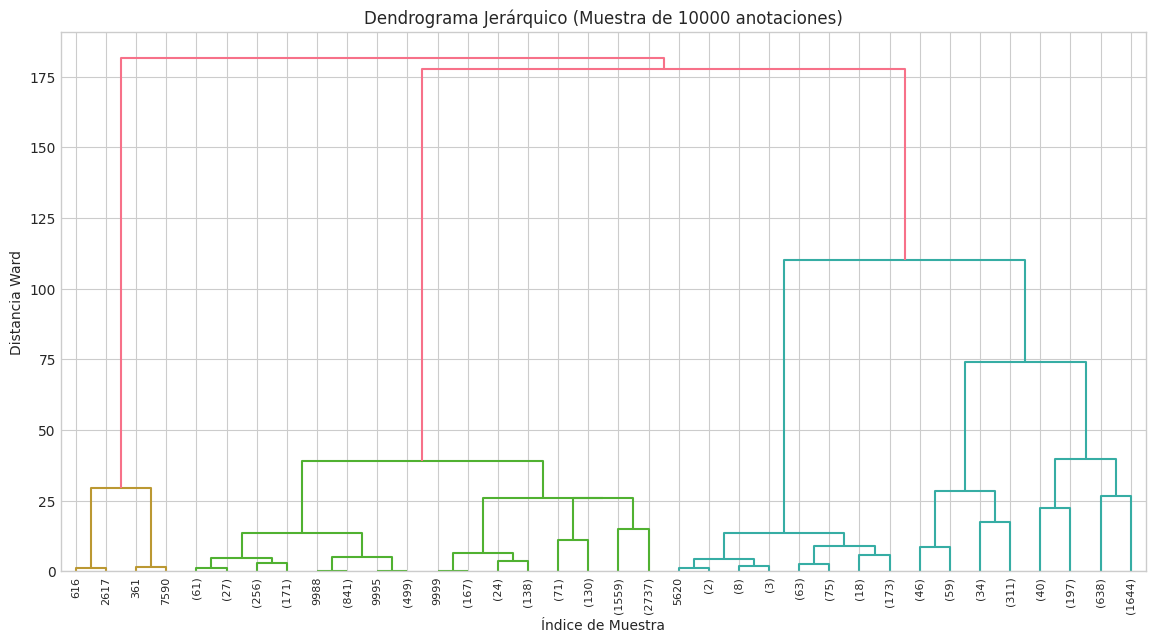

Calculando método del codo...
✓ Gráfico guardado: ../reports/eda/elbow_method.png


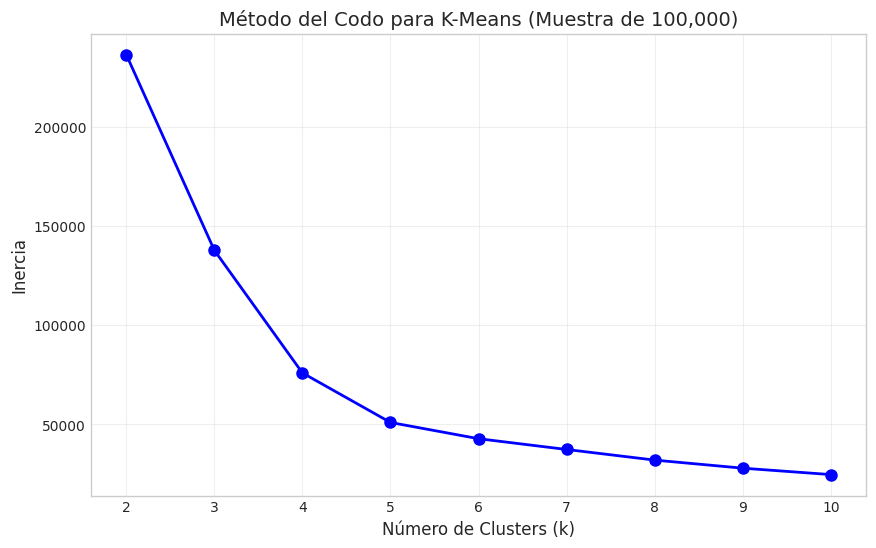

El valor óptimo de k determinado por el método del codo es: 4

Aplicando Mini-Batch K-Means con k=4...

Distribución de tipos de entidades por cluster (Top 25 por cluster):

Cluster 0:
type_entity
FOOD     2863120
COLOR          3
Name: count, dtype: int64

Cluster 1:
type_entity
FOOD                2586996
QUANTITY               1179
UNIT                    996
PROCESS                 307
PHYSICAL_QUALITY        203
TASTE                    35
PURPOSE                  26
PART                     12
COLOR                     1
Name: count, dtype: int64

Cluster 2:
type_entity
FOOD     3151530
COLOR         49
Name: count, dtype: int64

Cluster 3:
type_entity
FOOD                403216
PROCESS                 65
PURPOSE                 21
PHYSICAL_QUALITY        16
QUANTITY                11
UNIT                     6
TASTE                    3
PART                     1
Name: count, dtype: int64
✓ Reporte guardado: ../reports/eda/cluster_type_entity_full.csv

Estadísticas por cluster:


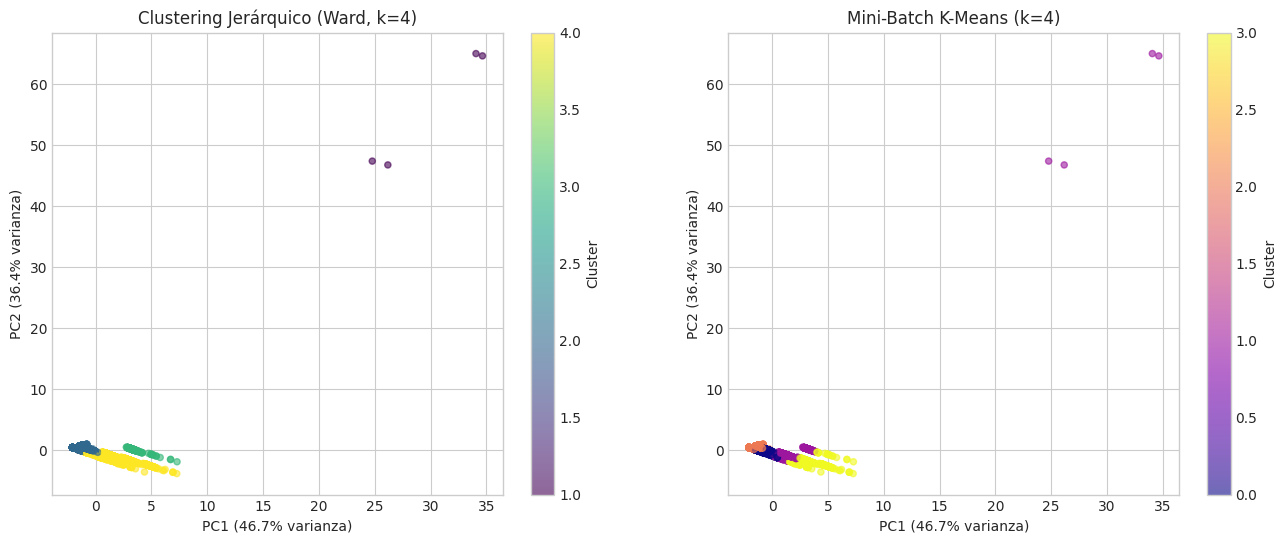

✓ Reporte guardado: ../reports/eda/clustering_report.json
RAM liberada: 0.00 MB
RAM actual: 15048.27 MB


In [14]:
# =============================================================================
# SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN
# =============================================================================
print_section("SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN")
liberar_ram()

clustering_report = {}

# Importar KneeLocator para encontrar el codo
from kneed import KneeLocator

# Preparación de datos para clustering (incluyendo nuevas columnas)
print("Preparando datos para clustering...")
df_cluster_full = main_with_entities.select([
    "entity_length_chars", "entity_length_tokens", "type_entity", "iob_tag"
]).to_pandas()

# Encode categóricas
le_type = LabelEncoder().fit(df_cluster_full["type_entity"])
df_cluster_full["type_encoded"] = le_type.transform(df_cluster_full["type_entity"])

le_iob = LabelEncoder().fit(df_cluster_full["iob_tag"])
df_cluster_full["iob_encoded"] = le_iob.transform(df_cluster_full["iob_tag"])

features_full = df_cluster_full[["entity_length_chars", "entity_length_tokens", "type_encoded", "iob_encoded"]].values
scaler = StandardScaler()
features_scaled_full = scaler.fit_transform(features_full)

# Muestreo estratificado para dendrograma
sample_size = 10000
df_sample = main_with_entities.sample(n=min(sample_size, len(main_with_entities)), seed=42).to_pandas()
df_sample["type_encoded"] = le_type.transform(df_sample["type_entity"])
df_sample["iob_encoded"] = le_iob.transform(df_sample["iob_tag"])
features_sample = df_sample[["entity_length_chars", "entity_length_tokens", "type_encoded", "iob_encoded"]].values
features_scaled_sample = scaler.transform(features_sample)

# Dendrograma jerárquico
print("Generando dendrograma...")
Z = linkage(features_scaled_sample, method='ward')
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, ax=ax)
ax.set_title(f"Dendrograma Jerárquico (Muestra de {len(df_sample)} anotaciones)")
ax.set_xlabel("Índice de Muestra")
ax.set_ylabel("Distancia Ward")
plot_and_save(fig, 'dendrogram.png')

# Método del codo
print("Calculando método del codo...")
elbow_sample_size = min(100000, len(features_scaled_full))
elbow_indices = np.random.choice(len(features_scaled_full), elbow_sample_size, replace=False)
features_elbow = features_scaled_full[elbow_indices]

inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_elbow)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Inercia', fontsize=12)
ax.set_title(f'Método del Codo para K-Means (Muestra de {elbow_sample_size:,})', fontsize=14)
ax.grid(True, alpha=0.3)
plot_and_save(fig, 'elbow_method.png')

# K-Means óptimo: Determinar k automáticamente usando KneeLocator
kl = KneeLocator(K_range, inertias, S=1.0, curve="convex", direction="decreasing")
k_opt = int(kl.elbow if kl.elbow else K_range[0])  # Fallback to the smallest k if no clear elbow found
print(f"El valor óptimo de k determinado por el método del codo es: {k_opt}")

print(f"\nAplicando Mini-Batch K-Means con k={k_opt}...")
mb_kmeans = MiniBatchKMeans(n_clusters=k_opt, random_state=42, batch_size=1024, n_init=3)
mb_kmeans.fit(features_scaled_full)
df_cluster_full['cluster'] = mb_kmeans.labels_

# Análisis de clusters
print("\nDistribución de tipos de entidades por cluster (Top 25 por cluster):")
for cluster in sorted(df_cluster_full['cluster'].unique()):
    top_types = df_cluster_full[df_cluster_full['cluster'] == cluster]['type_entity'].value_counts().head(25)
    print(f"\nCluster {cluster}:")
    print(top_types)

# Guardar la distribución completa
cluster_summary_full = df_cluster_full.groupby(['cluster', 'type_entity']).size().unstack(fill_value=0)
save_report(cluster_summary_full, 'cluster_type_entity_full.csv', 'csv')

cluster_means = df_cluster_full.groupby('cluster').agg({
    'entity_length_chars': ['mean', 'std', 'min', 'max'],
    'entity_length_tokens': ['mean', 'std', 'min', 'max'],
    'type_entity': 'count'
})
print("\nEstadísticas por cluster:")
print(cluster_means)

# Análisis de IOB tags por cluster
print("\nDistribución de IOB tags por cluster (Top 25 por cluster):")
for cluster in sorted(df_cluster_full['cluster'].unique()):
    top_iob = df_cluster_full[df_cluster_full['cluster'] == cluster]['iob_tag'].value_counts().head(25)
    print(f"\nCluster {cluster}:")
    print(top_iob)

# Guardar completa
cluster_iob_dist_full = df_cluster_full.groupby(['cluster', 'iob_tag']).size().unstack(fill_value=0)
save_report(cluster_iob_dist_full, 'cluster_iob_tag_full.csv', 'csv')

# Ensure k_opt is a standard Python int for JSON serialization
clustering_report['optimal_k'] = k_opt
clustering_report['inertias'] = {int(k): float(inertia) for k, inertia in zip(K_range, inertias)}

# PCA para visualización
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters jerárquicos
num_clusters_hier = k_opt  # Usar k_opt para consistencia
clusters_hier = fcluster(Z, t=num_clusters_hier, criterion='maxclust')
scatter1 = axes[0].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=clusters_hier, cmap='viridis', alpha=0.6, s=20)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[0].set_title(f'Clustering Jerárquico (Ward, k={num_clusters_hier})')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: K-Means en muestra
df_sample['cluster_kmeans'] = mb_kmeans.predict(features_scaled_sample)
scatter2 = axes[1].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=df_sample['cluster_kmeans'], cmap='plasma', alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[1].set_title(f'Mini-Batch K-Means (k={k_opt})')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plot_and_save(fig, 'clustering_pca.png')

save_report(clustering_report, 'clustering_report.json')

del df_cluster_full, features_full, features_scaled_full, df_sample, features_sample, features_scaled_sample, Z, features_elbow, inertias, mb_kmeans, cluster_summary_full, cluster_means, cluster_iob_dist_full, features_pca, clusters_hier
liberar_ram()


SECCIÓN 8: ANÁLISIS DE CORRELACIONES
RAM liberada: 0.00 MB
RAM actual: 15048.27 MB
✓ Gráfico guardado: ../reports/eda/correlation_matrix.png


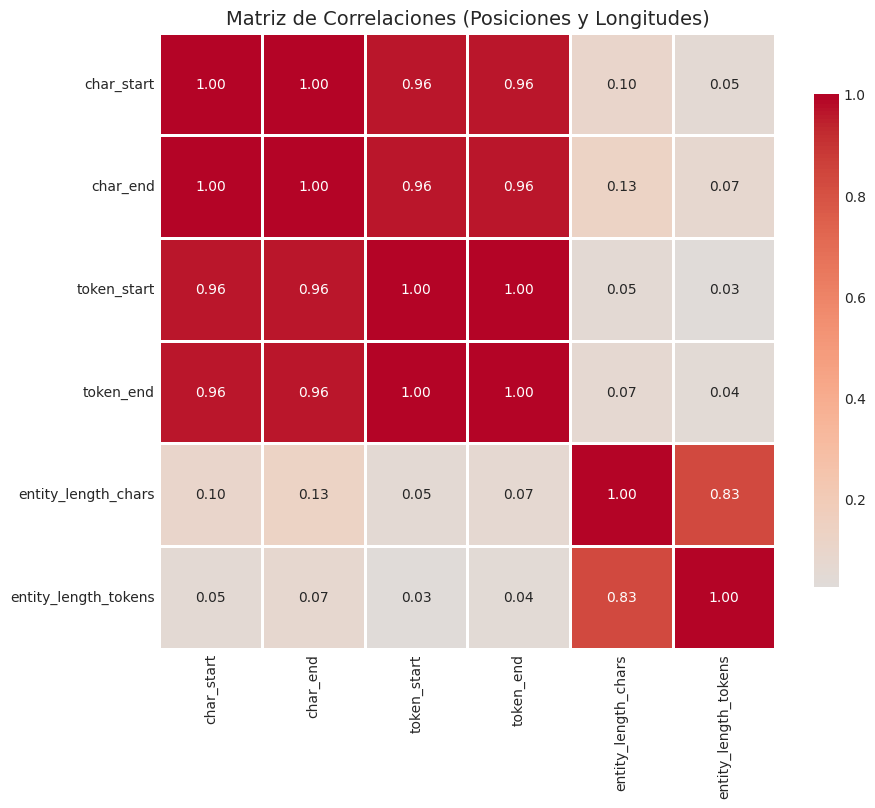


Correlaciones más fuertes (|r| > 0.5, excluyendo diagonales):
  token_start <-> token_end: 1.000
  char_start <-> char_end: 1.000
  char_start <-> token_end: 0.963
  char_start <-> token_start: 0.963
  char_end <-> token_end: 0.962
  char_end <-> token_start: 0.961
  entity_length_chars <-> entity_length_tokens: 0.833
RAM liberada: 0.00 MB
RAM actual: 15268.37 MB


In [15]:
# =============================================================================
# SECCIÓN 8: ANÁLISIS DE CORRELACIONES
# =============================================================================
print_section("SECCIÓN 8: ANÁLISIS DE CORRELACIONES")
liberar_ram()

# Correlaciones numéricas
corr_cols = ["char_start", "char_end", "token_start", "token_end", 
             "entity_length_chars", "entity_length_tokens"]
corr_df = main_with_entities.select(corr_cols).to_pandas().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de Correlaciones (Posiciones y Longitudes)", fontsize=14)
plot_and_save(fig, 'correlation_matrix.png')

# Correlaciones destacables
print("\nCorrelaciones más fuertes (|r| > 0.5, excluyendo diagonales):")
corr_pairs = []
for i in range(len(corr_df.columns)):
    for j in range(i+1, len(corr_df.columns)):
        corr_val = corr_df.iloc[i, j]
        if abs(corr_val) > 0.5:
            corr_pairs.append({
                'var1': corr_df.columns[i],
                'var2': corr_df.columns[j],
                'correlation': corr_val
            })

for pair in sorted(corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
    print(f"  {pair['var1']} <-> {pair['var2']}: {pair['correlation']:.3f}")

del corr_df, corr_pairs
liberar_ram()

In [16]:
# =============================================================================
# SECCIÓN 9: ANÁLISIS DE ENTIDADES ESPECÍFICAS
# =============================================================================
print_section("SECCIÓN 9: ANÁLISIS DE ENTIDADES ESPECÍFICAS")

entity_analysis = {}

# Top entidades más frecuentes
print("\n--- Top 20 Entidades Más Frecuentes ---")
entity_freq = main_with_entities.group_by("entity").agg([
    pl.count().alias("frequency"),
    pl.col("type_entity").first().alias("type")
]).sort("frequency", descending=True)

print(entity_freq.head(20))

# Entidades que aparecen con un solo tipo vs múltiples
entity_type_variety = main_with_entities.group_by("entity").agg([
    pl.col("type_entity").n_unique().alias("num_types"),
    pl.count().alias("total_occurrences")
])

single_type = entity_type_variety.filter(pl.col("num_types") == 1)
multi_type = entity_type_variety.filter(pl.col("num_types") > 1)

print(f"\nEntidades con tipo único: {len(single_type)} ({100*len(single_type)/len(entity_type_variety):.1f}%)")
print(f"Entidades con múltiples tipos: {len(multi_type)} ({100*len(multi_type)/len(entity_type_variety):.1f}%)")

entity_analysis['single_type_entities'] = len(single_type)
entity_analysis['multi_type_entities'] = len(multi_type)

# Análisis de capitalización por tipo
caps_by_type = main_with_entities.group_by("type_entity").agg([
    pl.col("is_all_caps").mean().alias("pct_all_caps"),
    pl.col("is_capitalized").mean().alias("pct_capitalized"),
    pl.col("has_numbers").mean().alias("pct_with_numbers")
]).sort("pct_all_caps", descending=True)

print("\nCaracterísticas textuales por tipo (top 10):")
print(caps_by_type.head(10))

# Tokens más comunes en entidades (análisis básico de palabras)
print("\n--- Análisis de Tokens en Entidades ---")
all_tokens = main_with_entities["entity"].str.split(" ").explode().str.to_lowercase()
token_freq = all_tokens.value_counts().head(30)
print("Top 30 tokens más frecuentes en entidades:")
print(token_freq)

save_report(entity_analysis, 'entity_analysis.json')

del entity_freq, entity_type_variety, single_type, multi_type, caps_by_type, all_tokens, token_freq
liberar_ram()


SECCIÓN 9: ANÁLISIS DE ENTIDADES ESPECÍFICAS

--- Top 20 Entidades Más Frecuentes ---


shape: (20, 3)
┌───────────────┬───────────┬──────┐
│ entity        ┆ frequency ┆ type │
│ ---           ┆ ---       ┆ ---  │
│ str           ┆ u32       ┆ str  │
╞═══════════════╪═══════════╪══════╡
│ salt          ┆ 457252    ┆ FOOD │
│ sugar         ┆ 322798    ┆ FOOD │
│ butter        ┆ 268551    ┆ FOOD │
│ flour         ┆ 245362    ┆ FOOD │
│ eggs          ┆ 210094    ┆ FOOD │
│ …             ┆ …         ┆ …    │
│ brown sugar   ┆ 74897     ┆ FOOD │
│ baking powder ┆ 71567     ┆ FOOD │
│ oil           ┆ 69202     ┆ FOOD │
│ margarine     ┆ 66682     ┆ FOOD │
│ cheese        ┆ 65369     ┆ FOOD │
└───────────────┴───────────┴──────┘

Entidades con tipo único: 115305 (99.9%)
Entidades con múltiples tipos: 173 (0.1%)

Características textuales por tipo (top 10):
shape: (9, 4)
┌──────────────────┬──────────────┬─────────────────┬──────────────────┐
│ type_entity      ┆ pct_all_caps ┆ pct_capitalized ┆ pct_with_numbers │
│ ---              ┆ ---          ┆ ---             ┆ ---         

In [17]:
# =============================================================================
# SECCIÓN 10: CASOS EXTREMOS Y MUESTRAS PARA REVISIÓN MANUAL
# =============================================================================
print_section("SECCIÓN 10: CASOS EXTREMOS PARA REVISIÓN MANUAL")

extreme_cases = {}

# 1. Entidades más largas
print("\n--- Top 15 Entidades Más Largas ---")
longest_entities = main_with_entities.sort("entity_length_chars", descending=True).head(15).select([
    "sentence_id", "entity", "type_entity", "entity_length_chars", "iob_tag"
])
print(longest_entities)
save_report(longest_entities.to_pandas(), 'longest_entities.csv', 'csv')

# 2. Entidades más cortas (posibles errores)
print("\n--- Entidades Más Cortas (1 char) ---")
shortest_entities = main_with_entities.filter(pl.col("entity_length_chars") == 1).head(20).select([
    "sentence_id", "entity", "type_entity"
])
print(shortest_entities)
extreme_cases['single_char_entities'] = len(main_with_entities.filter(pl.col("entity_length_chars") == 1))

# 3. Oraciones con más entidades
print("\n--- Top 10 Oraciones Con Más Entidades ---")
most_annotated = sentences_with_annots.sort("num_entities", descending=True).head(10).select([
    "sentence_id", "num_entities", "sentence_length_chars", "num_tokens"
])
print(most_annotated)

# Obtener texto de estas oraciones para inspección
if len(most_annotated) > 0:
    top_sent_ids = most_annotated["sentence_id"].to_list()
    top_sentences_full = sentences_df.filter(pl.col("sentence_id").is_in(top_sent_ids)).select([
        "sentence_id", "sentence"
    ]).join(most_annotated, on="sentence_id")
    
    print("\nTexto completo de las 5 oraciones con más entidades:")
    for row in top_sentences_full.head(5).iter_rows(named=True):
        print(f"\nSentence ID: {row['sentence_id']} ({row['num_entities']} entidades)")
        print(f"Texto: {row['sentence'][:200]}..." if len(row['sentence']) > 200 else f"Texto: {row['sentence']}")

# 4. Entidades con caracteres especiales inusuales
print("\n--- Entidades con Caracteres Especiales ---")
special_char_entities = main_with_entities.filter(
    pl.col("entity").str.contains(r"[^\w\s\-']")  # No alfanumérico, espacio, guión o apóstrofo
).head(20).select(["entity", "type_entity"])
print(special_char_entities)
extreme_cases['entities_with_special_chars'] = len(main_with_entities.filter(
    pl.col("entity").str.contains(r"[^\w\s\-']")
))

# 5. Entidades numéricas puras
print("\n--- Entidades Numéricas Puras ---")
numeric_entities = main_with_entities.filter(
    pl.col("entity").str.contains(r"^\d+$")
).head(20).select(["entity", "type_entity"])
print(numeric_entities)
extreme_cases['pure_numeric_entities'] = len(main_with_entities.filter(
    pl.col("entity").str.contains(r"^\d+$")
))

save_report(extreme_cases, 'extreme_cases.json')

del longest_entities, shortest_entities, most_annotated, top_sentences_full, special_char_entities, numeric_entities
liberar_ram()


SECCIÓN 10: CASOS EXTREMOS PARA REVISIÓN MANUAL

--- Top 15 Entidades Más Largas ---
shape: (15, 5)
┌──────────────┬─────────────────────────────────┬─────────────┬─────────────────────┬─────────┐
│ sentence_id  ┆ entity                          ┆ type_entity ┆ entity_length_chars ┆ iob_tag │
│ ---          ┆ ---                             ┆ ---         ┆ ---                 ┆ ---     │
│ str          ┆ str                             ┆ str         ┆ i64                 ┆ str     │
╞══════════════╪═════════════════════════════════╪═════════════╪═════════════════════╪═════════╡
│ SENT_2330932 ┆ http://www.foodnetwork.com/rec… ┆ FOOD        ┆ 145                 ┆         │
│ SENT_861103  ┆ http://www.foodnetwork.com/rec… ┆ FOOD        ┆ 137                 ┆         │
│ SENT_1969507 ┆ http://www.foodnetwork.com/rec… ┆ FOOD        ┆ 132                 ┆         │
│ SENT_629255  ┆ http://www.foodnetwork.com/rec… ┆ FOOD        ┆ 128                 ┆         │
│ SENT_2497709 ┆ http://ww


SECCIÓN 11: RESUMEN EJECUTIVO

RESUMEN EJECUTIVO
{
  "dataset_overview": {
    "total_annotations": 9007796,
    "unique_entities": 370140,
    "annotated_sentences": 1121796,
    "total_sentences": 1121796,
    "coverage_pct": 100.0,
    "num_entity_types": 9
  },
  "sentences_overview": {
    "mean_sentence_length_chars": 578.4796130490748,
    "median_sentence_length_chars": 426.0,
    "max_sentence_length_chars": 14966.0,
    "mean_num_tokens": 108.31082656739729,
    "median_num_tokens": 81.0,
    "max_num_tokens": 2783.0,
    "num_without_entities": 0,
    "pct_without_entities": 0.0,
    "pct_all_caps": 9.003419516560943e-05,
    "pct_capitalized": 0.7268353604398661,
    "pct_with_numbers": 0.9423816808047096,
    "pct_with_special_chars": 0.9999491886225303,
    "mean_entity_density_chars": 0.01925830710336647,
    "max_entity_density_chars": 0.8260869565217391,
    "mean_entity_density_tokens": 0.1002352993618618,
    "max_entity_density_tokens": 4.75,
    "mean_ttr": 0.7610

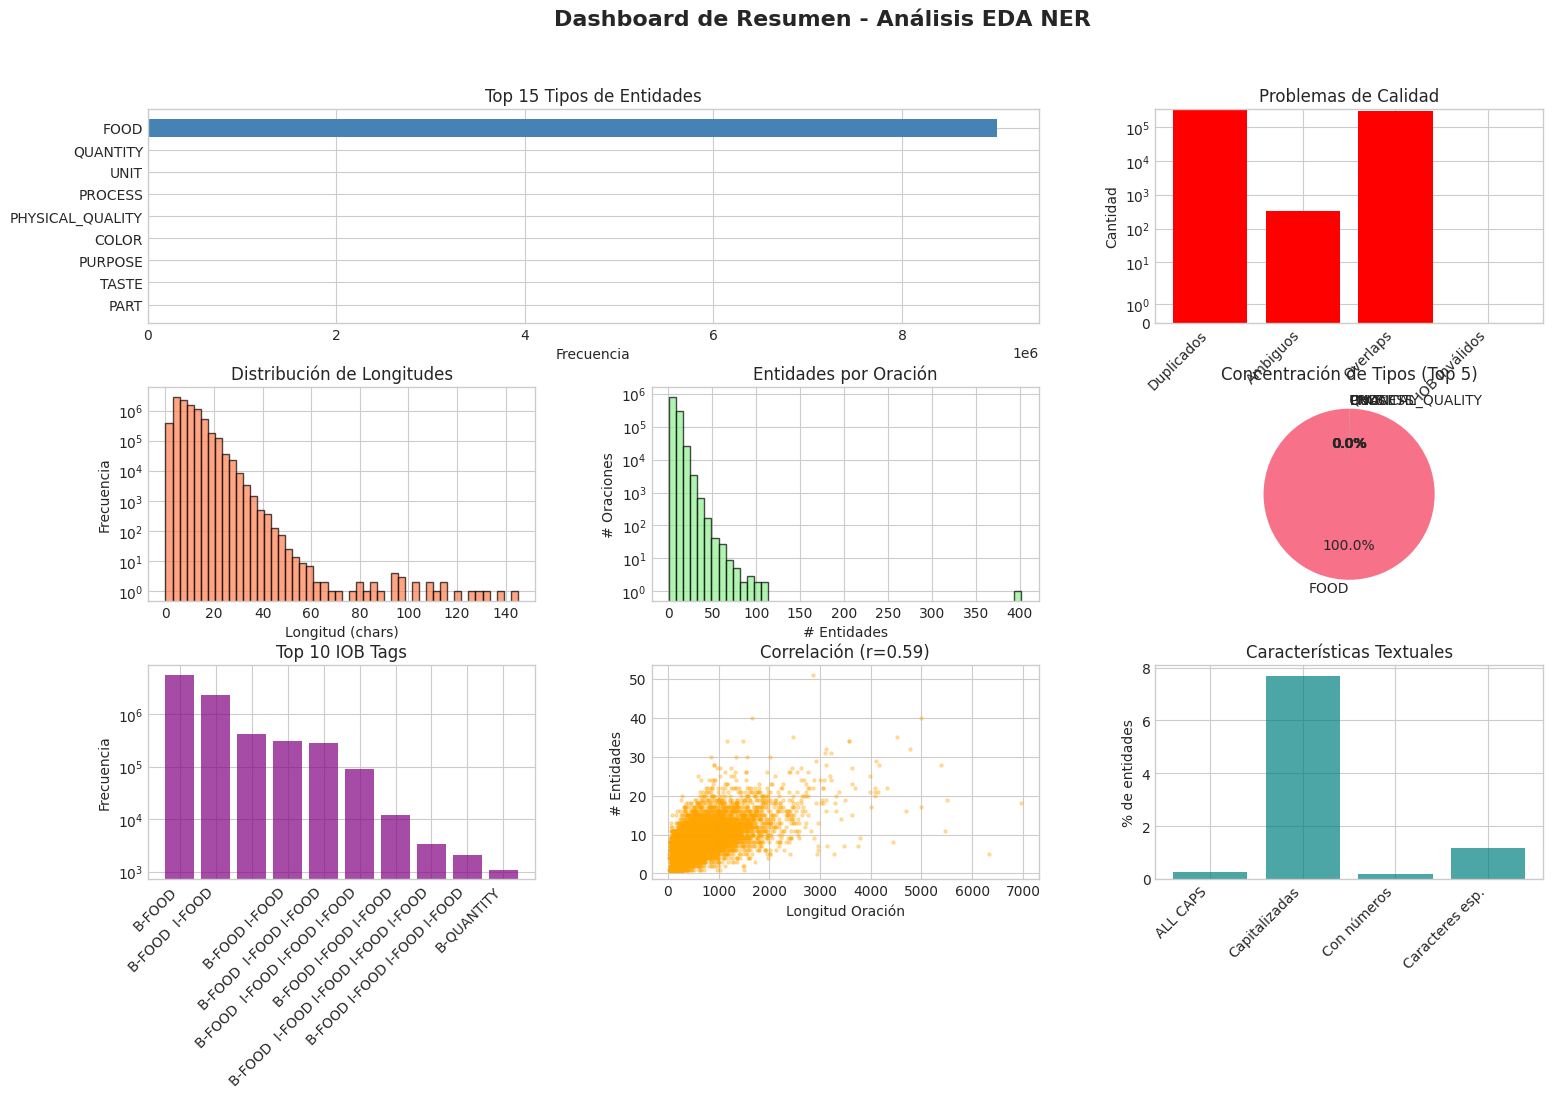

RAM liberada: 0.00 MB
RAM actual: 15756.43 MB


In [18]:
# =============================================================================
# SECCIÓN 11: RESUMEN EJECUTIVO Y EXPORTACIÓN FINAL
# =============================================================================
print_section("SECCIÓN 11: RESUMEN EJECUTIVO")

executive_summary = {
    "dataset_overview": {
        "total_annotations": total_annots,
        "unique_entities": unique_entities,
        "annotated_sentences": unique_sentences,
        "total_sentences": total_sentences,
        "coverage_pct": float(coverage),
        "num_entity_types": len(type_dist)
    },
    "sentences_overview": sentences_stats,
    "quality_metrics": quality_report,
    "imbalance_metrics": {
        "gini_coefficient": float(gini),
        "entropy": float(ent),
        "max_min_ratio": float(max_ratio)
    },
    "top_5_types": type_dist.head(5).to_pandas().to_dict('records'),
    "length_statistics": {
        "mean_entity_length": float(main_with_entities["entity_length_chars"].mean()),
        "median_entity_length": float(main_with_entities["entity_length_chars"].median()),
        "max_entity_length": int(main_with_entities["entity_length_chars"].max()),
        "mean_sentence_length": float(sentences_df["sentence_length_chars"].mean())
    },
    "iob_validation": iob_report,
    "clustering": {
        "optimal_clusters": k_opt,
        "pca_variance_explained": float(pca.explained_variance_ratio_.sum())
    },
    "extreme_cases": extreme_cases,
    "recommendations": [
        "Revisar anotaciones duplicadas" if quality_report.get('duplicates', 0) > 0 else "✓ No hay duplicados",
        "Resolver entidades ambiguas con múltiples tipos" if quality_report.get('ambiguous_entities', 0) > 0 else "✓ No hay ambigüedades",
        "Corregir overlaps de anotaciones" if quality_report.get('overlaps', 0) > 0 else "✓ No hay overlaps",
        "Validar secuencias IOB inválidas" if iob_report.get('invalid_sequences', 0) > 0 else "✓ Secuencias IOB válidas",
        f"Considerar estratificación por tipo (Gini={gini:.2f})" if gini > 0.6 else "✓ Balance aceptable de tipos",
        "Revisar entidades de 1 carácter" if extreme_cases.get('single_char_entities', 0) > 100 else "✓ Pocas entidades de 1 char"
    ]
}

print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)
print(json.dumps(executive_summary, indent=2, ensure_ascii=False))

save_report(executive_summary, 'executive_summary.json')

# Gráfico de resumen final
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Distribución de tipos (barras horizontales, top 15)
ax1 = fig.add_subplot(gs[0, :2])
top15_dist = type_dist.head(15).to_pandas()

# Eliminar filas donde type_entity es None o NaN para evitar errores en el gráfico
top15_dist = top15_dist[top15_dist["type_entity"].notnull()]

# Convertir type_entity a string explícitamente (por si acaso)
top15_dist["type_entity"] = top15_dist["type_entity"].astype(str)

ax1.barh(top15_dist["type_entity"], top15_dist["count"], color='steelblue')
ax1.set_xlabel("Frecuencia")
ax1.set_title("Top 15 Tipos de Entidades")
ax1.invert_yaxis()

# 2. Métricas de calidad
ax2 = fig.add_subplot(gs[0, 2])
quality_metrics = [
    quality_report.get('duplicates', 0),
    quality_report.get('ambiguous_entities', 0),
    quality_report.get('overlaps', 0),
    iob_report.get('invalid_sequences', 0)
]
quality_labels = ['Duplicados', 'Ambiguos', 'Overlaps', 'IOB Inválidos']
colors_quality = ['red' if m > 0 else 'green' for m in quality_metrics]
ax2.bar(range(len(quality_metrics)), quality_metrics, color=colors_quality)
ax2.set_xticks(range(len(quality_labels)))
ax2.set_xticklabels(quality_labels, rotation=45, ha='right')
ax2.set_ylabel("Cantidad")
ax2.set_title("Problemas de Calidad")
ax2.set_yscale('symlog')

# 3. Distribución de longitudes
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(main_with_entities["entity_length_chars"].to_numpy(), bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel("Longitud (chars)")
ax3.set_ylabel("Frecuencia")
ax3.set_title("Distribución de Longitudes")
ax3.set_yscale('log')

# 4. Entidades por oración
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(sentences_with_annots["num_entities"].to_numpy(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax4.set_xlabel("# Entidades")
ax4.set_ylabel("# Oraciones")
ax4.set_title("Entidades por Oración")
ax4.set_yscale('log')

# 5. Desbalance (pie chart)
ax5 = fig.add_subplot(gs[1, 2])
top5_counts = type_dist.head(5)["count"].to_numpy()
others = type_dist["count"].sum() - top5_counts.sum()
pie_data = list(top5_counts) + [others]
pie_labels = type_dist.head(5)["type_entity"].to_list() + ['Otros']
ax5.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax5.set_title("Concentración de Tipos (Top 5)")

# 6. IOB distribution
ax6 = fig.add_subplot(gs[2, 0])
iob_top = iob_dist.head(10).to_pandas()
ax6.bar(range(len(iob_top)), iob_top["count"], color='purple', alpha=0.7)
ax6.set_xticks(range(len(iob_top)))
ax6.set_xticklabels(iob_top["iob_tag"], rotation=45, ha='right')
ax6.set_ylabel("Frecuencia")
ax6.set_title("Top 10 IOB Tags")
ax6.set_yscale('log')

# 7. Correlación longitud-entidades
ax7 = fig.add_subplot(gs[2, 1])
scatter_sample = sentences_with_annots.sample(n=min(10000, len(sentences_with_annots)), seed=42).to_pandas()
ax7.scatter(scatter_sample["sentence_length_chars"], scatter_sample["num_entities"], 
            alpha=0.3, s=5, color='orange')
ax7.set_xlabel("Longitud Oración")
ax7.set_ylabel("# Entidades")
ax7.set_title(f"Correlación (r={corr_length_annots:.2f})")

# 8. Características textuales
ax8 = fig.add_subplot(gs[2, 2])
char_features_pct = [
    100 * caps_stats["all_caps"][0] / total_annots,
    100 * caps_stats["capitalized"][0] / total_annots,
    100 * caps_stats["with_numbers"][0] / total_annots,
    100 * caps_stats["with_special_chars"][0] / total_annots
]
char_labels = ['ALL CAPS', 'Capitalizadas', 'Con números', 'Caracteres esp.']
ax8.bar(range(len(char_features_pct)), char_features_pct, color='teal', alpha=0.7)
ax8.set_xticks(range(len(char_labels)))
ax8.set_xticklabels(char_labels, rotation=45, ha='right')
ax8.set_ylabel("% de entidades")
ax8.set_title("Características Textuales")

fig.suptitle("Dashboard de Resumen - Análisis EDA NER", fontsize=16, fontweight='bold')
plot_and_save(fig, 'executive_dashboard.png')

del top15_dist, quality_metrics, top5_counts, pie_data, iob_top, scatter_sample, char_features_pct
liberar_ram()

In [19]:
# =============================================================================
# FINALIZACIÓN
# =============================================================================
print("\n" + "="*80)
print("✓ EDA COMPLETADO EXITOSAMENTE")
print("="*80)
print(f"\nReportes generados en: {REPORT_DIR}")
print("\nArchivos creados:")
for report_file in sorted(REPORT_DIR.glob("*")):
    print(f"  - {report_file.name}")

print("\n" + "="*80)
print("RECOMENDACIONES FINALES:")
print("="*80)
for i, rec in enumerate(executive_summary['recommendations'], 1):
    print(f"{i}. {rec}")

print("\n¡Análisis completado! Revisa los reportes y visualizaciones generadas.")
print("="*80)

# Liberar variables restantes al final
del main_df, entities_df, sentences_df, main_with_entities, sentences_with_annots, type_dist, caps_stats
liberar_ram()


✓ EDA COMPLETADO EXITOSAMENTE

Reportes generados en: ../reports/eda

Archivos creados:
  - Graficos Eda.pdf
  - ambiguous_entities.csv
  - basic_stats.json
  - cluster_iob_tag_full.csv
  - cluster_type_entity_full.csv
  - clustering_pca.png
  - clustering_report.json
  - cooccurrence_report.json
  - cooccurrences.csv
  - correlation_matrix.png
  - dendrogram.png
  - elbow_method.png
  - entity_analysis.json
  - executive_dashboard.png
  - executive_summary.json
  - extreme_cases.json
  - iob_validation_report.json
  - json_to_txt.py
  - longest_entities.csv
  - post_preprocess_stats_sampled.json
  - preprocess_report.json
  - quality_report.json
  - sentences_analysis.png
  - sentences_distribution.png
  - sentences_stats.json
  - text_analysis.json
  - text_analysis.png
  - top_bigrams_sentences.csv
  - top_words_sentences.csv
  - txts
  - type_distribution.png
  - type_stats.json

RECOMENDACIONES FINALES:
1. Revisar anotaciones duplicadas
2. Resolver entidades ambiguas con múltiple

In [20]:
# =============================================================================
# PREPROCESADO AJUSTADO (MUESTREO 33% AL INICIO)
# =============================================================================
print_section("PREPROCESADO AJUSTADO CON MUESTREO DEL 33% AL INICIO")

preprocess_report = {}

# Paso 1: Muestreo del 33% desde el inicio
print("\n--- Paso 1: Muestreo del 33% ---")
sample_fraction = 0.33
random_seed = 42
print(f"Aplicando muestreo del {sample_fraction*100:.0f}% de los datos con semilla {random_seed}...")

# Muestreo de sentences_df
sentences_df_sampled = sentences_df.sample(fraction=sample_fraction, seed=random_seed)
print(f"Dataset original sentences_df: {sentences_df.height} filas. Dataset muestreado: {sentences_df_sampled.height} filas.")

# Filtrar main_with_entities para mantener solo sentence_id en la muestra
main_with_entities_sampled = main_with_entities.filter(pl.col("sentence_id").is_in(sentences_df_sampled["sentence_id"]))
print(f"Dataset original main_with_entities: {main_with_entities.height} filas. Dataset muestreado: {main_with_entities_sampled.height} filas.")

# Actualizar DataFrames para trabajar con la muestra
sentences_df = sentences_df_sampled
main_with_entities = main_with_entities_sampled
preprocess_report['sampled_sentences'] = sentences_df.height
preprocess_report['sampled_annotations'] = main_with_entities.height

# Validación inicial: Verificar columnas esperadas y nulos
expected_columns_main = ["sentence_id", "entity_id", "entity", "type_entity", "iob_tag", "char_start", "char_end", "token_start", "token_end", "entity_length_chars", "entity_length_tokens"]
expected_columns_sentences = ["sentence_id", "sentence", "sentence_length_chars", "num_tokens"]
missing_cols_main = [col for col in expected_columns_main if col not in main_with_entities.columns]
missing_cols_sentences = [col for col in expected_columns_sentences if col not in sentences_df.columns]
if missing_cols_main:
    raise ValueError(f"Columnas faltantes en main_with_entities: {missing_cols_main}")
if missing_cols_sentences:
    raise ValueError(f"Columnas faltantes en sentences_df: {missing_cols_sentences}")
print("✓ Columnas verificadas en main_with_entities:", main_with_entities.columns)
print("✓ Columnas verificadas en sentences_df:", sentences_df.columns)

# Verificar nulos (aunque EDA reportó 0, para robustez)
null_counts_main = main_with_entities.null_count()
null_counts_sentences = sentences_df.null_count()
if any(null_counts_main[col][0] > 0 for col in expected_columns_main):
    print("⚠️ Nulos detectados en main_with_entities:", {col: int(null_counts_main[col][0]) for col in null_counts_main.columns})
    main_with_entities = main_with_entities.drop_nulls(subset=["sentence_id", "entity", "type_entity"])
if any(null_counts_sentences[col][0] > 0 for col in expected_columns_sentences):
    print("⚠️ Nulos detectados en sentences_df:", {col: int(null_counts_sentences[col][0]) for col in null_counts_sentences.columns})
    sentences_df = sentences_df.drop_nulls(subset=["sentence_id", "sentence"])
print(f"Shape inicial main_with_entities (muestreado): {main_with_entities.shape}")
print(f"Shape inicial sentences_df (muestreado): {sentences_df.shape}")


PREPROCESADO AJUSTADO CON MUESTREO DEL 33% AL INICIO

--- Paso 1: Muestreo del 33% ---
Aplicando muestreo del 33% de los datos con semilla 42...


NameError: name 'sentences_df' is not defined

In [ ]:
# Paso 2: Normalización de texto y filtrado a solo FOOD
print("\n--- Paso 2: Normalización de Texto y Filtrado a FOOD ---")
main_with_entities = main_with_entities.filter(pl.col("type_entity") == "FOOD")

main_with_entities = main_with_entities.with_columns([
    # ENTITY: Normalización robusta
    # Consideraciones culinarias:
    # - Eliminar símbolos potencialmente conflictivos o no culinarios (por ejemplo: °, ™, ®, ©, €, £, ¥, «», ·, †, ‡, …, •, ª, º, &, @, etc.)
    # - Mantener guiones, letras, números y espacios (para nombres compuestos y números como "pan-rojo" o "queso 4 quesos")
    # - Eliminar caracteres de temperatura (°) solo si están asociados a números (ej. "180°c" → "180c")
    # - Permitir letras acentuadas y eñes (importante en español culinario)
    pl.col("entity")
      .str.to_lowercase()
      .str.replace_all(r"[\n\t\r]", " ")
      # Reemplazo robusto de temperaturas tipo "200°", "180°c", "90ºf", "120º", cualquier variante de ° u º (U+00B0, U+00BA)
      .str.replace_all(r"(\d+)\s*[°º]\s*[cf]?", r"\1\3")
      # Elimina símbolos problemáticos y "noise" frecuente en scraps culinarios internacionales
      .str.replace_all(r"[™®©€£¥«»†‡…•ªº&@%₩₹₽₦₴₪§#=|^~\[\]{}\*/\\<>\$]", "")
      # Elimina °/º/·/• restantes (raro fuera del contexto temperatura)
      .str.replace_all(r"[°º·•]", "")
      # Mantener sólo letras (incluidos acentos y ñ), números, espacios y guiones
      .str.replace_all(r"[^\w\s\-áéíóúüñÁÉÍÓÚÜÑ]", "")
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("entity"),
    pl.col("iob_tag").str.to_uppercase().alias("iob_tag")
])

sentences_df = sentences_df.with_columns([
    # SENTENCE: Permitir puntuación culinaria relevante y hacer limpieza robusta como arriba
    pl.col("sentence")
      .str.to_lowercase()
      .str.replace_all(r"[\n\t\r]", " ")
      .str.replace_all(r"(\d+)\s*[°º]\s*[cf]?", r"\1\3")
      .str.replace_all(r"[™®©€£¥«»†‡…•ªº&@%₩₹₽₦₴₪§#=|^~\[\]{}\*/\\<>\$]", "")
      .str.replace_all(r"[°º·•]", "")
      .str.replace_all(r"[^\w\s.,;:/!?\-áéíóúüñÁÉÍÓÚÜÑ]", "")
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("sentence")
])

# Recalcular features derivadas después de normalización
main_with_entities = main_with_entities.with_columns([
    (pl.col("char_end") - pl.col("char_start")).alias("entity_length_chars"),
    (pl.col("token_end") - pl.col("token_start") + 1).alias("entity_length_tokens")
])

sentences_df = sentences_df.with_columns([
    pl.col("sentence").str.len_chars().alias("sentence_length_chars"),
    pl.col("sentence").str.split(" ").list.len().alias("num_tokens")
])

# Filtrar entidades numéricas puras (no queremos ingredientes que sean solo números)
main_with_entities = main_with_entities.filter(~pl.col("entity").str.contains(r"^\d+$"))

print(f"Shape después de normalización y filtrado numéricos en main_with_entities: {main_with_entities.shape}")
preprocess_report['numeric_entities_removed'] = main_with_entities_sampled.height - main_with_entities.height


--- Paso 2: Normalización de Texto y Filtrado a FOOD ---


NameError: name 'main_with_entities' is not defined

In [ ]:
# Paso 3: Eliminación de duplicados
print("\n--- Paso 3: Eliminación de Duplicados ---")
main_with_entities = main_with_entities.unique(subset=["sentence_id", "char_start", "char_end", "entity"], keep="first")
print(f"Shape después de unique en main_with_entities: {main_with_entities.shape}")
preprocess_report['duplicates_removed'] = main_with_entities_sampled.height - main_with_entities.height


--- Paso 3: Eliminación de Duplicados ---
Shape después de unique en main_with_entities: (2917545, 12)


In [ ]:
# Paso 4: Resolver Overlaps
print("\n--- Paso 4: Resolver Overlaps ---")
main_sorted = main_with_entities.sort(["sentence_id", "char_start"])
overlaps = main_sorted.with_columns([
    pl.col("char_end").shift(1).over("sentence_id").alias("prev_end"),
    pl.col("sentence_id").shift(1).alias("prev_sent")
]).filter(
    (pl.col("sentence_id") == pl.col("prev_sent")) & 
    (pl.col("char_start") < pl.col("prev_end"))
)

if len(overlaps) > 0:
    to_keep = []
    current_sent = None
    active_entities = []
    
    for row in main_sorted.iter_rows(named=True):
        if row["sentence_id"] != current_sent:
            active_entities = []
            current_sent = row["sentence_id"]
        
        overlaps_with = [e for e in active_entities if row["char_start"] < e["char_end"] and row["char_end"] > e["char_start"]]
        
        if overlaps_with:
            all_overlapping = overlaps_with + [row]
            max_length_entity = max(all_overlapping, key=lambda x: x["entity_length_chars"])
            active_entities = [e for e in active_entities if e not in overlaps_with]
            if max_length_entity not in active_entities:
                active_entities.append(max_length_entity)
        else:
            active_entities.append(row)
        
        to_keep.extend(active_entities)
    
    main_with_entities = pl.DataFrame(to_keep).unique()
    print(f"Shape después de resolver overlaps: {main_with_entities.shape}")
preprocess_report['overlaps_resolved'] = len(overlaps)


--- Paso 4: Resolver Overlaps ---


Shape después de resolver overlaps: (2877220, 12)


In [ ]:
# Paso 5: Eliminar longitudes inválidas
print("\n--- Paso 5: Eliminar Longitudes Inválidas ---")
main_with_entities = main_with_entities.filter(
    (pl.col("entity_length_chars") > 0) & 
    (pl.col("entity_length_tokens") > 0)
)
print(f"Shape después de eliminar longitudes inválidas: {main_with_entities.shape}")
preprocess_report['invalid_lengths_removed'] = main_with_entities_sampled.height - main_with_entities.height


--- Paso 5: Eliminar Longitudes Inválidas ---
Shape después de eliminar longitudes inválidas: (2761486, 12)


In [ ]:
# Paso 6: Revisar entidades extremas
print("\n--- Paso 6: Revisar Entidades Extremas ---")
main_with_entities = main_with_entities.filter(pl.col("entity_length_chars") > 1)  # Eliminar de un solo char
print(f"Shape después de eliminar entidades de un solo char: {main_with_entities.shape}")
preprocess_report['single_char_removed'] = main_with_entities_sampled.height - main_with_entities.height

main_with_entities = main_with_entities.filter(~pl.col("entity").str.contains(r"[^\w\s-]"))  # Eliminar con especiales no alfanum
print(f"Shape después de eliminar con especiales: {main_with_entities.shape}")
preprocess_report['special_chars_removed'] = main_with_entities_sampled.height - main_with_entities.height


--- Paso 6: Revisar Entidades Extremas ---
Shape después de eliminar entidades de un solo char: (2759867, 12)
Shape después de eliminar con especiales: (2759867, 12)


In [ ]:
# Paso 7: Limpieza mejorada de sentences_df
print("\n--- Paso 7: Limpieza Mejorada de Sentences_df ---")
# Agregar features derivadas para limpieza
sentences_df = sentences_df.with_columns([
    # Proporción de caracteres especiales
    (pl.col("sentence").str.count_matches(r"[^\w\s]") / pl.col("sentence_length_chars")).alias("special_ratio"),
    # TTR
    pl.col("sentence").str.to_lowercase().str.split(" ").map_elements(
        lambda words: len(set(words)) / len(words) if len(words) > 0 else 0.0, 
        return_dtype=pl.Float64
    ).alias("ttr")
])


--- Paso 7: Limpieza Mejorada de Sentences_df ---


In [ ]:
# Eliminar oraciones muy largas (>5,000 caracteres)
sentences_df = sentences_df.filter(pl.col("sentence_length_chars") <= 5000)
print(f"Shape después de eliminar oraciones muy largas: {sentences_df.shape}")
preprocess_report['very_long_sentences_removed'] = sentences_df_sampled.height - sentences_df.height

# Eliminar oraciones con baja diversidad léxica (TTR < 0.5 * mean = 0.3806)
sentences_df = sentences_df.filter(pl.col("ttr") >= 0.3806)
print(f"Shape después de eliminar oraciones con baja TTR: {sentences_df.shape}")
preprocess_report['low_ttr_sentences_removed'] = sentences_df_sampled.height - sentences_df.height

# Eliminar oraciones con alta proporción de caracteres especiales (>50%)
sentences_df = sentences_df.filter(pl.col("special_ratio") <= 0.5)
print(f"Shape después de eliminar oraciones con alta proporción de especiales: {sentences_df.shape}")
preprocess_report['high_special_ratio_removed'] = sentences_df_sampled.height - sentences_df.height

Shape después de eliminar oraciones muy largas: (370054, 6)
Shape después de eliminar oraciones con baja TTR: (369960, 6)
Shape después de eliminar oraciones con alta proporción de especiales: (369960, 6)


In [ ]:
# Calcular densidad de entidades
sentences_with_annots = main_with_entities.group_by("sentence_id").agg([
    pl.count().alias("num_entities"),
    pl.col("entity_length_chars").mean().alias("avg_entity_length"),
    pl.col("entity_length_chars").max().alias("max_entity_length")
]).join(sentences_df, on="sentence_id", how="left")

sentences_df = sentences_with_annots.with_columns([
    (pl.col("num_entities") / pl.col("sentence_length_chars")).alias("entity_density_chars"),
    (pl.col("num_entities") / pl.col("num_tokens")).alias("entity_density_tokens")
])

# Eliminar oraciones con alta densidad de entidades (>2x media = 0.2004)
sentences_df = sentences_df.filter(pl.col("entity_density_tokens") <= 0.2004)
print(f"Shape después de eliminar oraciones con alta densidad de entidades: {sentences_df.shape}")
preprocess_report['high_density_sentences_removed'] = sentences_df_sampled.height - sentences_df.height

Shape después de eliminar oraciones con alta densidad de entidades: (346988, 11)


In [ ]:
# Filtrar main_with_entities para mantener solo sentence_id en sentences_df
main_with_entities = main_with_entities.filter(pl.col("sentence_id").is_in(sentences_df["sentence_id"]))

# Validar coherencia: Verificar que entity esté en sentence
joined = main_with_entities.join(sentences_df, on="sentence_id")
mismatches = joined.filter(pl.col("sentence").str.slice(pl.col("char_start"), pl.col("entity_length_chars")) != pl.col("entity"))
if len(mismatches) > 0:
    main_with_entities = main_with_entities.filter(~pl.col("entity_id").is_in(mismatches["entity_id"]))
    print(f"Eliminadas {len(mismatches)} anotaciones con mismatch")
preprocess_report['mismatches_removed'] = len(mismatches)

Eliminadas 1036793 anotaciones con mismatch


In [ ]:
# Paso 8: Agregar features derivadas y clustering a sentences_df
print("\n--- Paso 8: Agregar Features Derivadas y Clustering ---")
sentences_df = sentences_df.with_columns([
    pl.col("sentence").str.to_lowercase().str.split(" ").map_elements(
        lambda words: len(set(words)) / len(words) if len(words) > 0 else 0.0, 
        return_dtype=pl.Float64
    ).alias("ttr")
])

# Clustering en sentences_df
df_cluster = sentences_df.select([
    "sentence_length_chars", "num_tokens", "entity_density_chars", "entity_density_tokens", "ttr"
]).to_pandas()

features = df_cluster.values
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

k_opt = 4  # De EDA
mb_kmeans = MiniBatchKMeans(n_clusters=k_opt, random_state=42, batch_size=1024, n_init=3)
mb_kmeans.fit(features_scaled)
sentences_df = sentences_df.with_columns(pl.Series("cluster", mb_kmeans.labels_).cast(pl.Int32))
print("Clusters agregados (0-3).")


--- Paso 8: Agregar Features Derivadas y Clustering ---
Clusters agregados (0-3).


In [ ]:
# =============================================================================
# Paso 9: Guardar y Reportar
# =============================================================================
print("\n--- Paso 9: Guardar y Reportar ---")

# NOTA: Las siguientes verificaciones y salidas detalladas están centradas en SENT_2012004 por debugging,
# pero el guardado y el procesamiento son para *todos* los datos.

# Ejemplo de chequeo puntual para una frase problemática:
sent_id_debug = "SENT_2012004"
print(f"¿main_with_entities contiene '{sent_id_debug}'?", bool((main_with_entities.filter(pl.col("sentence_id") == sent_id_debug)).height))
print(f"¿sentences_df contiene '{sent_id_debug}'?", bool((sentences_df.filter(pl.col("sentence_id") == sent_id_debug)).height))

_debug_entities = main_with_entities.filter(pl.col("sentence_id") == sent_id_debug)["entity"]
print(f"Entities para {sent_id_debug}:", _debug_entities)

# El pipeline siguiente procesa todas las frases (no solo una):
annotations_grouped = main_with_entities.group_by("sentence_id").agg([
    pl.col("entity").alias("entities")
])

df_final = sentences_df.select(["sentence_id", "sentence"]).join(annotations_grouped, on="sentence_id", how="left")

print(f"df_final muestra {sent_id_debug} tras join:")
print(df_final.filter(pl.col("sentence_id") == sent_id_debug))

# Reemplazar None en entities con lista vacía para TODO el df
df_final = df_final.with_columns(
    pl.when(pl.col("entities").is_null())
     .then([])
     .otherwise(pl.col("entities"))
     .alias("entities")
)
# Convertir columna de lista a string (para TODO el df, no solo para un id)
df_final = df_final.with_columns(
    pl.col("entities").list.join(" | ").alias("entities")
)

print(f"df_final muestra {sent_id_debug} tras convertir a str:")
print(df_final.filter(pl.col("sentence_id") == sent_id_debug))

# ------ GUARDADO PARA TODO EL DATASET ------
output_parquet_path = Path("../data/process/") / "ner_preprocessed_sampled.parquet"
df_final.write_parquet(output_parquet_path)
print(f"Dataset preprocesado muestreado guardado en: {output_parquet_path}")

output_csv_path = Path("../data/process/") / "ner_preprocessed_sampled.csv"
df_final.write_csv(output_csv_path, separator=',')
print(f"Dataset preprocesado muestreado guardado en: {output_csv_path} (CSV con ',')")

# Generar JSON para Label Studio (TODO el dataset)
output_json_path = Path("../data/process/") / "ner_preprocessed_sampled.json"
print("Generando JSON con estructura específica para el dataset muestreado...")

df_dict_list = df_final.to_dicts()
json_data = []
for idx, row in enumerate(df_dict_list, 1):
    json_entry = {
        "id": idx,
        "data": {
            "sentence_id": row["sentence_id"],
            "sentence": row["sentence"],
            "entities": row.get("entities", "")  # Robustez
        },
        "annotations": [],
        "predictions": []
    }
    json_data.append(json_entry)

with open(output_json_path, 'w', encoding='utf-8') as f:
    json.dump(json_data, f, indent=2, ensure_ascii=False)

print(f"Dataset preprocesado muestreado guardado en: {output_json_path} (JSON con estructura específica)")

# ------ Reportes para TODO el dataset ------
post_stats = {
    "total_sentences": df_final.height,
    "total_annotations": main_with_entities.height
}
save_report(preprocess_report, 'preprocess_report.json')
save_report(post_stats, 'post_preprocess_stats_sampled.json')
print("Reporte de preprocesado:", preprocess_report)
print("Stats post-preprocess (muestreado):", post_stats)

liberar_ram()


--- Paso 9: Guardar y Reportar ---
¿main_with_entities contiene 'SENT_2012004'? True
¿sentences_df contiene 'SENT_2012004'? True
Entities para SENT_2012004: shape: (7,)
Series: 'entity' [str]
[
	"tomatoes"
	"onions"
	"hot peppers"
	"salt"
	"sugar"
	"vinegar"
	"oil"
]
df_final muestra SENT_2012004 tras join:
shape: (1, 3)
┌──────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ sentence_id  ┆ sentence                        ┆ entities                        │
│ ---          ┆ ---                             ┆ ---                             │
│ str          ┆ str                             ┆ list[str]                       │
╞══════════════╪═════════════════════════════════╪═════════════════════════════════╡
│ SENT_2012004 ┆ 1 gal. peeled tomatoes, 2 c. c… ┆ ["tomatoes", "onions", … "oil"… │
└──────────────┴─────────────────────────────────┴─────────────────────────────────┘
df_final muestra SENT_2012004 tras convertir a str:
shape: (1, 3)
┌──────────────